# 4 — Top feature report

A reader-only report containing sixteen views: one per-horizon feature table, one three-hour aggregate feature table, one count-based top-100 data-source chart, and one importance-weighted top-100 data-source chart for each of **Normal**, **Arcsinh**, **Spikes**, and **Dips**. Each feature-table row contains the top 10 optimally selected, non-duplicate features for that horizon or time block.

Every cell shows the feature name and its LightGBM **gain-share importance**. For each objective and horizon, a feature's raw gain is divided by the total gain across all ranked candidate features before the optimal-feature mask is applied. The resulting 0–1 value is the feature's actual share of the ranking model's total gain; no feature is forced to equal 1. Three-hour importance is the arithmetic mean across six consecutive 30-minute horizons, with an unselected feature contributing zero for that horizon. Heatmap colours are scaled independently within each horizon or three-hour row, while the printed values remain the actual gain shares. This notebook reads existing feature-selection artifacts and does not write to the pipeline.

In [1]:
import sys
from io import BytesIO
from html import escape
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import HTML, Image, display
import matplotlib.pyplot as plt
from matplotlib import colormaps, colors
import pyarrow.parquet as pq


def find_project_root(start):
    """Find the repository root whether Jupyter starts here or higher up."""
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "EPF" / "variables.py").exists():
            return candidate
    raise FileNotFoundError("Could not find a parent containing EPF/variables.py")


PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))
from EPF import variables

OBJECTIVES = ["normal", "arcsinh", "spikes", "dips"]
OBJECTIVE_LABELS = {
    "normal": "Normal",
    "arcsinh": "Arcsinh",
    "spikes": "Spikes",
    "dips": "Dips",
}
TOP_N = 10
HORIZON_MINUTES = int(variables.HORIZON_GRANULARITY_IN_MINUTES)
SELECTED_FEATURES_DIR = Path(variables.CWD) / "4_Features_select" / "Selected_features"


In [2]:
top_features_by_objective = {}
selected_importance_by_objective = {}

for objective in OBJECTIVES:
    raw_gains = pd.read_csv(
        SELECTED_FEATURES_DIR / f"features_ranked_values_{objective}.csv",
        index_col=0,
    )
    raw_gains.columns = [column.removeprefix("target_") for column in raw_gains.columns]
    ranked_unique = pd.read_parquet(
        SELECTED_FEATURES_DIR / f"FEATURES_RANKED_ORDERED_UNIQUE_{objective}.parquet"
    )
    optimal = (
        pd.read_parquet(
            SELECTED_FEATURES_DIR / f"FEATURES_OPTIMAL_AMOUNT_{objective}.parquet"
        )
        .set_index("feature")
        .astype(bool)
    )

    missing_unique = optimal.index.difference(ranked_unique.index)
    missing_gains = optimal.index.difference(raw_gains.index)
    missing_horizons = optimal.columns.difference(raw_gains.columns)
    if len(missing_unique) or len(missing_gains) or len(missing_horizons):
        raise ValueError(
            f"{objective}: inconsistent inputs; missing unique={len(missing_unique)}, "
            f"gains={len(missing_gains)}, horizons={len(missing_horizons)}"
        )

    # Standard gain-share importance: raw feature gain / total gain from every
    # candidate feature in this objective/horizon. Apply the optimal-feature
    # mask only after calculating the shares so excluded features still count
    # in the denominator and the values retain their actual contribution scale.
    total_gain = raw_gains.sum(axis=0).replace(0.0, np.nan)
    normalized = (
        raw_gains.div(total_gain, axis=1)
        .reindex(index=optimal.index, columns=optimal.columns)
        .where(optimal)
        .clip(0.0, 1.0)
    )

    # Retain genuine all-zero selected horizons as importance 0 rather than NaN.
    for horizon in total_gain.index[total_gain.isna()]:
        normalized.loc[optimal[horizon], horizon] = 0.0
    selected_importance_by_objective[objective] = normalized

    horizon_columns = sorted(optimal.columns, key=lambda value: int(value.removeprefix("h")))
    feature_rows = []
    importance_rows = []
    row_labels = []

    for horizon in horizon_columns:
        chosen = normalized[horizon].dropna().sort_values(ascending=False, kind="stable").head(TOP_N)
        if len(chosen) != TOP_N:
            raise ValueError(f"{objective} {horizon}: expected {TOP_N} selected features, found {len(chosen)}")
        horizon_number = int(horizon.removeprefix("h"))
        lead_hours = horizon_number * HORIZON_MINUTES / 60
        row_labels.append(f"{horizon} · +{lead_hours:g}h")
        feature_rows.append(chosen.index.tolist())
        importance_rows.append(chosen.to_numpy(dtype=float).tolist())

    rank_columns = [f"Rank {rank}" for rank in range(1, TOP_N + 1)]
    feature_table = pd.DataFrame(feature_rows, index=row_labels, columns=rank_columns)
    importance_table = pd.DataFrame(importance_rows, index=row_labels, columns=rank_columns)
    feature_table.index.name = "Horizon"
    importance_table.index.name = "Horizon"

    scores = importance_table.to_numpy(dtype=float)
    if not np.isfinite(scores).all() or scores.min() < 0 or scores.max() > 1:
        raise ValueError(f"{objective}: importance values must be finite and between 0 and 1")

    top_features_by_objective[objective] = {
        "features": feature_table,
        "importance": importance_table,
    }

print(f"Prepared {len(OBJECTIVES)} per-horizon tables × {len(horizon_columns)} horizons × top {TOP_N} features.")

THREE_HOUR_HORIZONS = 3 * 60 // HORIZON_MINUTES
if THREE_HOUR_HORIZONS * HORIZON_MINUTES != 3 * 60:
    raise ValueError("Three hours is not an exact multiple of the horizon granularity")

top_features_3h_by_objective = {}
for objective in OBJECTIVES:
    normalized = selected_importance_by_objective[objective]
    horizon_columns = sorted(normalized.columns, key=lambda value: int(value.removeprefix("h")))
    feature_rows = []
    importance_rows = []
    row_labels = []

    for block_start in range(0, len(horizon_columns), THREE_HOUR_HORIZONS):
        block_columns = horizon_columns[block_start:block_start + THREE_HOUR_HORIZONS]
        # Missing means not selected for that horizon, so it contributes zero.
        block_importance = normalized[block_columns].fillna(0.0).mean(axis=1)
        chosen = block_importance.sort_values(ascending=False, kind="stable").head(TOP_N)
        if len(chosen) != TOP_N:
            raise ValueError(
                f"{objective} {block_columns[0]}–{block_columns[-1]}: "
                f"expected {TOP_N} features, found {len(chosen)}"
            )
        start_hour = block_start * HORIZON_MINUTES / 60
        end_hour = (block_start + len(block_columns)) * HORIZON_MINUTES / 60
        row_labels.append(
            f"{start_hour:g}–{end_hour:g}h · {block_columns[0]}–{block_columns[-1]}"
        )
        feature_rows.append(chosen.index.tolist())
        importance_rows.append(chosen.to_numpy(dtype=float).tolist())

    rank_columns = [f"Rank {rank}" for rank in range(1, TOP_N + 1)]
    feature_table = pd.DataFrame(feature_rows, index=row_labels, columns=rank_columns)
    importance_table = pd.DataFrame(importance_rows, index=row_labels, columns=rank_columns)
    feature_table.index.name = "Three-hour block"
    importance_table.index.name = "Three-hour block"
    top_features_3h_by_objective[objective] = {
        "features": feature_table,
        "importance": importance_table,
    }

print(
    f"Prepared {len(OBJECTIVES)} three-hour tables × "
    f"{len(row_labels)} blocks × top {TOP_N} features."
)


Prepared 4 per-horizon tables × 96 horizons × top 10 features.
Prepared 4 three-hour tables × 16 blocks × top 10 features.


In [3]:
HEATMAP_PALETTE = [
    colors.to_hex(colormaps["YlOrRd"](0.10 + 0.85 * index / 255), keep_alpha=False)
    for index in range(256)
]

HEATMAP_CSS = """
<style>
.top-feature-wrap {
  max-height: 900px; overflow: auto; border: 1px solid #d0d7de;
  border-radius: 6px; margin: 8px 0 28px 0; background: white;
}
.top-feature-table {
  border-collapse: separate; border-spacing: 0; color: #24292f;
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif;
  font-size: 11px; line-height: 1.25;
}
.top-feature-table caption {
  caption-side: top; text-align: left; padding: 11px 12px;
  font-size: 15px; font-weight: 700; color: #24292f; background: white;
}
.top-feature-table th, .top-feature-table td {
  border-right: 1px solid #d8dee4; border-bottom: 1px solid #d8dee4;
  padding: 6px 8px;
}
.top-feature-table thead th {
  position: sticky; top: 0; z-index: 3; background: #f6f8fa;
  text-align: center; min-width: 205px;
}
.top-feature-table tbody th {
  position: sticky; left: 0; z-index: 2; background: #f6f8fa;
  text-align: left; min-width: 90px; white-space: nowrap; font-weight: 650;
}
.top-feature-table thead th:first-child { left: 0; z-index: 4; min-width: 90px; }
.top-feature-table td {
  min-width: 205px; max-width: 240px; vertical-align: top;
  white-space: normal; overflow-wrap: anywhere;
}
.top-feature-table .feature-name { font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace; }
.top-feature-table .importance { margin-top: 4px; font-weight: 750; font-variant-numeric: tabular-nums; }
</style>
"""


def show_top_feature_table(objective, table_collection, scope_label):
    features = table_collection[objective]["features"]
    importance = table_collection[objective]["importance"]
    if features.shape != importance.shape:
        raise ValueError("Feature and importance tables must have the same shape")

    parts = [
        HEATMAP_CSS,
        '<div class="top-feature-wrap"><table class="top-feature-table">',
        f'<caption>{escape(OBJECTIVE_LABELS[objective])} · top {TOP_N} {escape(scope_label)}</caption>',
        '<thead><tr><th>Horizon / block</th>',
    ]
    parts.extend(f'<th>{escape(str(column))}</th>' for column in features.columns)
    parts.append('</tr></thead><tbody>')

    for row_number, horizon in enumerate(features.index):
        row_scores = importance.iloc[row_number].to_numpy(dtype=float)
        row_min = float(row_scores.min())
        row_span = float(row_scores.max() - row_min)
        parts.append(f'<tr><th>{escape(str(horizon))}</th>')
        for column_number in range(features.shape[1]):
            feature = str(features.iat[row_number, column_number])
            score = float(importance.iat[row_number, column_number])
            colour_score = (score - row_min) / row_span if row_span > 0 else 0.5
            palette_index = int(round(np.clip(colour_score, 0.0, 1.0) * 255))
            background = HEATMAP_PALETTE[palette_index]
            foreground = "#ffffff" if colour_score >= 0.72 else "#24292f"
            title = escape(
                f"{horizon} | {feature} | importance {score:.6f}", quote=True
            )
            parts.append(
                f'<td title="{title}" style="background:{background};color:{foreground}">'
                f'<div class="feature-name">{escape(feature)}</div>'
                f'<div class="importance">importance {score:.4f}</div>'
                '</td>'
            )
        parts.append('</tr>')

    parts.append('</tbody></table></div>')
    display(HTML(''.join(parts)))


## Table 1 — Normal

In [4]:
show_top_feature_table("normal", top_features_by_objective, "features per horizon")


Horizon / block,Rank 1,Rank 2,Rank 3,Rank 4,Rank 5,Rank 6,Rank 7,Rank 8,Rank 9,Rank 10
h1 · +0.5h,nsw_price_rmean_4importance 0.4837,predispatch_rrp_nsw_h3importance 0.0329,xs_nsw_residual_demand_ramp_1himportance 0.0100,nsw_price_rmax_8importance 0.0053,pd_price_nsw_fmean_6himportance 0.0045,nsw_price_lag_282importance 0.0043,nsw_price_rstd_4importance 0.0039,vre_ramp_nsw_30mimportance 0.0030,xs_nsw_price_to_gasimportance 0.0023,nsw_price_rmin_8importance 0.0016
h2 · +1h,predispatch_rrp_nsw_h3importance 0.6133,nsw_price_rmean_4importance 0.0184,pd_price_nsw_fmean_6himportance 0.0114,xs_nsw_residual_demand_ramp_1himportance 0.0080,nsw_price_lag_276importance 0.0080,predispatch_rrp_nsw_h5importance 0.0035,demand_mom_nsw_1himportance 0.0034,qld_price_lag_276importance 0.0033,demand_ramp_nsw_30mimportance 0.0030,nsw_price_rmax_8importance 0.0028
h3 · +1.5h,predispatch_rrp_nsw_h3importance 0.0713,pd_price_nsw_fmean_6himportance 0.0181,predispatch_rrp_nsw_h5importance 0.0159,nsw_price_lag_264importance 0.0088,xs_nsw_residual_demand_ramp_1himportance 0.0043,nsw_price_rmean_4importance 0.0036,predispatch_rrp_nsw_h71importance 0.0032,demand_mom_nsw_1himportance 0.0031,pd_price_nsw_fmax_6himportance 0.0029,nsw_price_lag_276importance 0.0028
h4 · +2h,predispatch_rrp_nsw_h5importance 0.5487,nsw_price_lag_264importance 0.0209,pd_price_nsw_fmean_6himportance 0.0165,pd_price_nsw_fmax_6himportance 0.0093,qld_price_lag_264importance 0.0048,pd_price_nsw_fspikes_6himportance 0.0045,predispatch_rrp_nsw_h7importance 0.0035,demand_mom_nsw_1himportance 0.0030,nsw_price_mom_24himportance 0.0024,predispatch_rrp_nsw_h54importance 0.0024
h5 · +2.5h,predispatch_rrp_nsw_h5importance 0.0674,predispatch_rrp_nsw_h7importance 0.0351,pd_price_nsw_fmax_6himportance 0.0264,pd_price_nsw_fmean_6himportance 0.0177,nsw_price_lag_264importance 0.0123,nsw_price_lag_252importance 0.0106,predispatch_rrp_nsw_h54importance 0.0042,qld_price_lag_264importance 0.0041,nsw_price_mom_24himportance 0.0034,qld_price_lag_180importance 0.0030
h6 · +3h,predispatch_rrp_nsw_h7importance 0.5482,nsw_price_lag_252importance 0.0219,pd_price_nsw_fmax_6himportance 0.0178,pd_price_nsw_fmean_6himportance 0.0121,nsw_price_asinh_rmean_288importance 0.0083,predispatch_rrp_nsw_h9importance 0.0070,qld_price_lag_252importance 0.0058,nsw_price_mom_24himportance 0.0030,qld_price_asinh_rmean_288importance 0.0026,qld_price_q90_2016importance 0.0016
h7 · +3.5h,predispatch_rrp_nsw_h7importance 0.0800,predispatch_rrp_nsw_h9importance 0.0280,pd_price_nsw_fmax_6himportance 0.0180,nsw_price_lag_252importance 0.0168,nsw_price_asinh_rmean_288importance 0.0123,nsw_price_lag_240importance 0.0054,qld_price_lag_252importance 0.0044,pd_price_nsw_fmean_6himportance 0.0035,qld_price_asinh_rmean_288importance 0.0027,nsw_price_mom_24himportance 0.0021
h8 · +4h,predispatch_rrp_nsw_h9importance 0.5581,nsw_price_lag_240importance 0.0216,pd_price_nsw_fmax_6himportance 0.0160,nsw_price_asinh_rmean_288importance 0.0100,qld_price_lag_240importance 0.0044,pd_price_nsw_fmean_6himportance 0.0027,qld_price_asinh_rmean_288importance 0.0026,predispatch_rrp_nsw_h12importance 0.0024,pd_price_nsw_fspikes_6himportance 0.0021,nsw_price_asinh_rmean_2016importance 0.0016
h9 · +4.5h,predispatch_rrp_nsw_h9importance 0.0902,pd_price_nsw_fmax_6himportance 0.0165,nsw_price_lag_240importance 0.0162,nsw_price_lag_228importance 0.0112,predispatch_rrp_nsw_h12importance 0.0095,nsw_price_asinh_rmean_288importance 0.0086,qld_price_lag_240importance 0.0078,nsw_price_asinh_rmean_2016importance 0.0037,qld_price_asinh_rmean_288importance 0.0032,nsw_price_mom_24himportance 0.0020
h10 · +5h,predispatch_rrp_nsw_h12importance 0.0453,nsw_price_lag_228importance 0.0253,nsw_price_asinh_rmean_288importance 0.0109,qld_price_q90_2016importance 0.0089,qld_price_lag_228importance 0.0069,pd_price_nsw_fmax_6himportance 0.0056,gas_price_nsw_lag_8064importance 0.0037,qld_price_asinh_rmean_288importance 0.0034,predispatch_rrp_nsw_h14importance 0.0027,qld_price_spike_cou

## Table 2 — Arcsinh

In [5]:
show_top_feature_table("arcsinh", top_features_by_objective, "features per horizon")


Horizon / block,Rank 1,Rank 2,Rank 3,Rank 4,Rank 5,Rank 6,Rank 7,Rank 8,Rank 9,Rank 10
h1 · +0.5h,nsw_price_rmean_4importance 0.4813,predispatch_rrp_nsw_h2importance 0.0634,predispatch_rrp_nsw_h4importance 0.0045,pd_price_nsw_fmean_6himportance 0.0044,nsw_price_lag_282importance 0.0044,xs_nsw_price_to_gasimportance 0.0040,xs_nsw_residual_demand_ramp_1himportance 0.0038,nsw_price_rmax_8importance 0.0022,predispatch_rrp_nsw_h1importance 0.0020,nsw_price_hours_since_spike_1000importance 0.0015
h2 · +1h,nsw_price_rmean_4importance 0.1454,predispatch_rrp_nsw_h4importance 0.0820,pd_price_nsw_fmean_6himportance 0.0239,predispatch_rrp_nsw_h2importance 0.0146,nsw_price_lag_276importance 0.0107,xs_nsw_residual_demand_ramp_1himportance 0.0063,qld_price_lag_276importance 0.0027,nsw_price_rmax_8importance 0.0022,nsw_price_hours_since_spike_150importance 0.0020,demand_ramp_nsw_30mimportance 0.0017
h3 · +1.5h,predispatch_rrp_nsw_h4importance 0.5044,pd_price_nsw_fmean_6himportance 0.0831,nsw_price_rmean_4importance 0.0242,pd_price_nsw_fspikes_6himportance 0.0129,nsw_price_lag_264importance 0.0089,nsw_price_lag_276importance 0.0084,qld_price_lag_276importance 0.0042,xs_nsw_residual_demand_ramp_1himportance 0.0035,pdpasa_demand10_nsw_h5importance 0.0021,qld_price_rstd_288importance 0.0018
h4 · +2h,pd_price_nsw_fmean_6himportance 0.0924,predispatch_rrp_nsw_h4importance 0.0812,pd_price_nsw_fspikes_6himportance 0.0222,nsw_price_lag_264importance 0.0212,predispatch_rrp_nsw_h7importance 0.0081,nsw_price_rmean_4importance 0.0054,qld_price_lag_264importance 0.0054,demand_ramp_nsw_30mimportance 0.0017,pdpasa_reserve_margin_vic_min_24himportance 0.0016,pdpasa_demand10_nsw_h7importance 0.0016
h5 · +2.5h,pd_price_nsw_fmean_6himportance 0.1166,predispatch_rrp_nsw_h7importance 0.0902,pd_price_nsw_fspikes_6himportance 0.0177,nsw_price_lag_264importance 0.0140,qld_price_lag_264importance 0.0082,nsw_price_lag_252importance 0.0064,pdpasa_demand10_nsw_h7importance 0.0023,pdpasa_reserve_margin_vic_min_24himportance 0.0019,gas_price_nsw_rstd_8064importance 0.0019,nsw_price_mom_24himportance 0.0013
h6 · +3h,predispatch_rrp_nsw_h7importance 0.5038,pd_price_nsw_fmean_6himportance 0.1209,nsw_price_lag_252importance 0.0264,pd_price_nsw_fspikes_6himportance 0.0067,qld_price_lag_252importance 0.0067,predispatch_rrp_nsw_h10importance 0.0032,pd_price_nsw_fspikes_39himportance 0.0027,gas_nsw_rmean_288importance 0.0013,pdpasa_reserve_margin_vic_min_24himportance 0.0012,predispatch_rrp_nsw_h55importance 0.0011
h7 · +3.5h,predispatch_rrp_nsw_h7importance 0.0627,pd_price_nsw_fmean_6himportance 0.0540,predispatch_rrp_nsw_h10importance 0.0159,nsw_price_lag_252importance 0.0146,nsw_price_lag_240importance 0.0079,qld_price_lag_252importance 0.0052,pd_price_nsw_fspikes_39himportance 0.0047,pd_price_nsw_fspikes_6himportance 0.0045,nsw_price_rmean_288importance 0.0030,gas_price_vicimportance 0.0021
h8 · +4h,predispatch_rrp_nsw_h10importance 0.1375,nsw_price_lag_240importance 0.0237,qld_price_lag_240importance 0.0058,pd_price_nsw_fmean_6himportance 0.0056,pd_price_nsw_fspikes_6himportance 0.0032,nsw_price_rmean_288importance 0.0028,pdpasa_demand90_nsw_h9importance 0.0025,pd_price_nsw_fstd_6himportance 0.0022,pdpasa_reserve_margin_vic_min_24himportance 0.0020,pd_price_nsw_fspikes_39himportance 0.0018
h9 · +4.5h,predispatch_rrp_nsw_h10importance 0.5634,nsw_price_lag_240importance 0.0173,nsw_price_lag_228importance 0.0078,qld_price_lag_240importance 0.0054,nsw_price_rmean_288importance 0.0049,pdpasa_demand90_nsw_h9importance 0.0046,predispatch_rrp_nsw_h13importance 0.0033,pd_price_nsw_fspikes_39himportance 0.0026,pd_price_nsw_fstd_6himportance 0.0024,predispatch_rrp_nsw_h15importance 0.0015
h10 · +5h,predispatch_rrp_nsw_h10importance 0.0848,nsw_price_lag_228importance 0.0269,predispatch_rrp_nsw_h13importance 0.0183,qld_price_lag_228importance 0.0057,pdpasa_demand90_nsw_h11importance 0.0042,nsw_price_rmean_288importance 0.0030,nsw_price_lag_72importance 0.0020,pd_price_vic_fmean_24himporta

## Table 3 — Spikes

In [6]:
show_top_feature_table("spikes", top_features_by_objective, "features per horizon")


Horizon / block,Rank 1,Rank 2,Rank 3,Rank 4,Rank 5,Rank 6,Rank 7,Rank 8,Rank 9,Rank 10
h1 · +0.5h,nsw_price_hours_since_spike_150importance 0.2237,nsw_price_rmean_4importance 0.0862,predispatch_netinterchange_nsw_h4importance 0.0860,pd_price_nsw_fstd_6himportance 0.0561,qld_price_vs_vic_price_spread_lag1importance 0.0307,pdpasa_maxsurplusreserve_nsw_h17importance 0.0295,interchange_nsw_lag_2016importance 0.0269,predispatch_rrp_nsw_h2importance 0.0241,sa_price_annual_rmean_576importance 0.0180,nsw_price_rmax_8importance 0.0163
h2 · +1h,predispatch_rrp_nsw_h2importance 0.0378,predispatch_rrp_nsw_h4importance 0.0199,nsw_price_hours_since_spike_150importance 0.0171,nsw_price_rmax_8importance 0.0138,xs_nsw_residual_demand_ramp_1himportance 0.0135,nsw_price_rmean_4importance 0.0116,pd_price_nsw_fmean_6himportance 0.0110,pd_price_nsw_fmax_6himportance 0.0086,pd_price_nsw_fspikes_6himportance 0.0073,nsw_price_lag_276importance 0.0072
h3 · +1.5h,predispatch_rrp_nsw_h4importance 0.2768,wind_nsw_lag_2016importance 0.1136,sa_price_rmean_144importance 0.1039,vic_price_lag_420importance 0.0631,qld_price_asinh_lag_288importance 0.0575,predispatch_netinterchange_nsw_h31importance 0.0199,bidstack_nsw_coal_mw_under_300importance 0.0168,demand_forecast_nsw_rstd_48importance 0.0165,pd_price_nsw_fmean_6himportance 0.0148,solarradiation_sydneyimportance 0.0140
h4 · +2h,predispatch_rrp_nsw_h6importance 0.0574,predispatch_rrp_nsw_h4importance 0.0421,pd_price_nsw_fspikes_6himportance 0.0369,pd_price_nsw_fmean_6himportance 0.0219,nsw_price_lag_264importance 0.0160,pd_price_nsw_fmax_6himportance 0.0109,qld_price_lag_264importance 0.0088,pdpasa_maxsparecapacity_nsw_h5importance 0.0033,dew_brisbaneimportance 0.0029,xs_nsw_residual_demand_ramp_1himportance 0.0023
h5 · +2.5h,predispatch_rrp_nsw_h6importance 0.5273,pd_price_nsw_fspikes_6himportance 0.0418,pd_price_nsw_fmax_6himportance 0.0154,qld_price_lag_264importance 0.0094,pd_price_nsw_fmean_6himportance 0.0084,pd_price_nsw_fspikes_39himportance 0.0074,nsw_price_lag_264importance 0.0071,nsw_price_lag_252importance 0.0069,pd_demand_vic_fmean_24himportance 0.0053,pdpasa_maxsparecapacity_nsw_h7importance 0.0048
h6 · +3h,predispatch_rrp_nsw_h8importance 0.0697,predispatch_rrp_nsw_h6importance 0.0350,pd_price_nsw_fspikes_6himportance 0.0245,nsw_price_lag_252importance 0.0183,pd_price_nsw_fspikes_39himportance 0.0177,pd_price_nsw_fmax_6himportance 0.0137,pd_price_nsw_fmean_6himportance 0.0083,qld_price_lag_252importance 0.0083,pdpasa_maxsparecapacity_nsw_h7importance 0.0042,sa_price_rmean_12096importance 0.0017
h7 · +3.5h,predispatch_rrp_nsw_h8importance 0.3803,qld_price_lag_252importance 0.1628,qld_price_rmin_288importance 0.0174,pd_price_nsw_fspikes_39himportance 0.0160,predispatch_netinterchange_nsw_h21importance 0.0122,wind_rstd_nsw_1dimportance 0.0117,pd_price_nsw_fspikes_6himportance 0.0092,predispatch_mwflow_vic1_nsw1_h42importance 0.0080,pdpasa_maxsparecapacity_nsw_h53importance 0.0078,pd_price_nsw_fmax_6himportance 0.0074
h8 · +4h,predispatch_rrp_nsw_h10importance 0.0637,winddir_adelaideimportance 0.0312,predispatch_rrp_nsw_h8importance 0.0234,nsw_price_lag_240importance 0.0164,demand_ramp_nsw_30mimportance 0.0103,pd_price_nsw_fspikes_39himportance 0.0100,qld_price_lag_240importance 0.0071,pd_price_nsw_fspikes_6himportance 0.0056,pd_price_nsw_fmax_6himportance 0.0053,qld_price_lag_324importance 0.0052
h9 · +4.5h,predispatch_rrp_nsw_h10importance 0.5290,qld_price_lag_240importance 0.0104,nsw_price_lag_240importance 0.0100,nsw_price_lag_228importance 0.0079,avail_gen_qldimportance 0.0064,pd_price_nsw_fspikes_39himportance 0.0058,pd_price_nsw_fspikes_6himportance 0.0037,pdpasa_maxsparecapacity_nsw_h11importance 0.0029,predispatch_rrp_nsw_h13importance 0.0027,predispatch_meteredmwflow_nsw1_qld1_h37importance 0.0022
h10 · +5h,nem_wind_totalimportance 0.0600,interchange_nsw_rstd_12importance 0.0334,predispatch_netinterchange_nsw_h54importance 0.0249,vic_price_asinh_lag_4importance 0.0238,nsw_price_lag_annua

## Table 4 — Dips

In [7]:
show_top_feature_table("dips", top_features_by_objective, "features per horizon")


Horizon / block,Rank 1,Rank 2,Rank 3,Rank 4,Rank 5,Rank 6,Rank 7,Rank 8,Rank 9,Rank 10
h1 · +0.5h,nsw_price_rmin_48importance 0.1022,predispatch_meteredmwflow_n_q_mnsp1_h49importance 0.0849,nsw_price_rmin_144importance 0.0668,vic_price_rmin_24importance 0.0358,qld_price_rmin_48importance 0.0357,pd_demand_qld_fmean_24himportance 0.0355,predispatch_mwflow_nsw1_qld1_h4importance 0.0313,gas_mw_qldimportance 0.0274,demand_rmin_nsw_1dimportance 0.0256,demand_nsw_lag_2importance 0.0200
h2 · +1h,nsw_price_rmean_4importance 0.0974,temp_melbourneimportance 0.0694,nem_avail_totalimportance 0.0510,predispatch_availablegeneration_nsw_h13importance 0.0422,wind_nsw_lag_2016importance 0.0304,predispatch_mwflow_vic1_nsw1_h3importance 0.0254,xs_nsw_residual_demandimportance 0.0238,nsw_price_rmin_8importance 0.0226,windspeed_sydney_rmean_288importance 0.0225,demand_forecast_nsw_rstd_288importance 0.0214
h3 · +1.5h,sealevelpressure_sydneyimportance 0.1706,wind_nsw_rmean_288importance 0.1034,sa_price_lag_582importance 0.0866,pdpasa_surplusreserve_nsw_h51importance 0.0761,coal_nsw_lag_288importance 0.0513,humidity_adelaideimportance 0.0431,nem_avail_totalimportance 0.0417,nsw_price_spike_intensity_2016importance 0.0276,visibility_adelaideimportance 0.0249,demand_forecast_nsw_lag_12importance 0.0216
h4 · +2h,predispatch_rrp_nsw_h5importance 0.3833,pd_price_nsw_fmean_6himportance 0.0510,xs_nsw_price_to_gasimportance 0.0072,demand_mom_nsw_1himportance 0.0071,predispatch_availableload_nsw_h6importance 0.0069,predispatch_rrp_nsw_h7importance 0.0069,nem_vre_penimportance 0.0063,nsw_price_neg_count_288importance 0.0050,demand_yoy_change_nswimportance 0.0039,dew_sydneyimportance 0.0037
h5 · +2.5h,qld_price_pct_rank_288importance 0.1279,pd_price_nsw_fmean_6himportance 0.0940,nsw_price_pct_rank_288importance 0.0918,predispatch_mwflow_nsw1_qld1_h17importance 0.0843,wind_nsw_lag_12importance 0.0408,ic_flow_t_v_mnsp1_fh1importance 0.0393,sa_price_spike_intensity_2016importance 0.0332,vic_price_asinh_lag_2016importance 0.0148,nsw_price_lag_1152importance 0.0147,predispatch_meteredmwflow_nsw1_qld1_h1importance 0.0141
h6 · +3h,predispatch_rrp_nsw_h7importance 0.2334,pd_price_nsw_fmean_6himportance 0.0638,demand_nsw_rstd_288importance 0.0597,solarenergy_melbourneimportance 0.0338,vic_price_rstd_144importance 0.0172,sa_price_rmin_8importance 0.0115,qld_price_asinh_lag_576importance 0.0111,pdpasa_maxsurplusreserve_nsw_h9importance 0.0078,vic_price_mom_2himportance 0.0078,interchange_nsw_lag_12importance 0.0074
h7 · +3.5h,predispatch_rrp_nsw_h7importance 0.0475,coal_mw_nswimportance 0.0123,dayofyearimportance 0.0065,sa_price_neg_count_288importance 0.0064,predispatch_availableload_nsw_h9importance 0.0057,sa_price_lag_228importance 0.0045,gas_mw_qldimportance 0.0041,pd_price_nsw_fstd_39himportance 0.0039,pd_price_nsw_fmax_39himportance 0.0035,sa_price_lag_240importance 0.0032
h8 · +4h,pdpasa_demand50_nsw_h48importance 0.1443,predispatch_meteredmwflow_vic1_nsw1_h1importance 0.1110,qld_price_lag_annual_+0importance 0.0621,gas_mw_qldimportance 0.0296,qld_price_lag_396importance 0.0259,vic_price_rmin_576importance 0.0250,avail_gen_nsw_rstd_288importance 0.0189,winddir_sydneyimportance 0.0171,qld_price_lag_864importance 0.0166,ic_flow_nsw1_qld1_fmean_24himportance 0.0104
h9 · +4.5h,predispatch_rrp_nsw_h10importance 0.2390,qld_price_lag_24importance 0.0787,qld_price_rstd_4importance 0.0489,dispatch_gen_nsw_rstd_48importance 0.0377,qld_price_rmean_24importance 0.0269,interchange_nsw_lag_576importance 0.0112,predispatch_availableload_nsw_h28importance 0.0098,sa_price_neg_count_288importance 0.0059,nsw_price_asinh_lag_2010importance 0.0057,winddir_melbourneimportance 0.0053
h10 · +5h,predispatch_mwflow_nsw1_qld1_h38importance 0.2196,xs_nsw_thermal_shareimportance 0.1029,bidstack_nsw_mw_under_50importance 0.0536,humidity_melbourneimportance 0.0526,nsw_price_lag_168importance 0.0484,predispatch_mwflow_vic1_nsw1_h5importance 0.0424,qld_price_lag_408importance 0.0287,pdpasa_maxspar

# Three-hour horizon aggregates

Each row aggregates six consecutive 30-minute horizons. Importance is the mean gain share across the six horizons; a feature that was not optimally selected for one of those horizons contributes zero there.

## Table 5 — Normal, three-hour blocks

In [8]:
show_top_feature_table("normal", top_features_3h_by_objective, "features per three-hour block")


Horizon / block,Rank 1,Rank 2,Rank 3,Rank 4,Rank 5,Rank 6,Rank 7,Rank 8,Rank 9,Rank 10
0–3h · h1–h6,predispatch_rrp_nsw_h3importance 0.1196,predispatch_rrp_nsw_h5importance 0.1062,predispatch_rrp_nsw_h7importance 0.0978,nsw_price_rmean_4importance 0.0844,pd_price_nsw_fmean_6himportance 0.0134,pd_price_nsw_fmax_6himportance 0.0095,nsw_price_lag_264importance 0.0070,nsw_price_lag_252importance 0.0054,xs_nsw_residual_demand_ramp_1himportance 0.0038,nsw_price_lag_276importance 0.0019
3–6h · h7–h12,predispatch_rrp_nsw_h12importance 0.1225,predispatch_rrp_nsw_h9importance 0.1127,predispatch_rrp_nsw_h7importance 0.0133,nsw_price_asinh_rmean_288importance 0.0121,nsw_price_lag_228importance 0.0097,pd_price_nsw_fmax_6himportance 0.0093,predispatch_rrp_nsw_h14importance 0.0073,nsw_price_lag_240importance 0.0072,nsw_price_lag_216importance 0.0061,qld_price_q90_2016importance 0.0059
6–9h · h13–h18,predispatch_rrp_nsw_h16importance 0.1181,predispatch_rrp_nsw_h14importance 0.1054,predispatch_rrp_nsw_h19importance 0.0954,qld_price_q90_2016importance 0.0148,nsw_price_lag_192importance 0.0105,nsw_price_asinh_rmean_288importance 0.0104,nsw_price_lag_204importance 0.0087,nsw_price_lag_180importance 0.0066,qld_price_asinh_rmean_288importance 0.0041,pd_price_nsw_fspikes_24himportance 0.0033
9–12h · h19–h24,predispatch_rrp_nsw_h24importance 0.1111,predispatch_rrp_nsw_h22importance 0.1080,qld_price_q90_2016importance 0.0168,predispatch_rrp_nsw_h26importance 0.0140,predispatch_rrp_nsw_h19importance 0.0129,nsw_price_lag_168importance 0.0111,nsw_price_lag_156importance 0.0110,nsw_price_lag_144importance 0.0081,nsw_price_asinh_rmean_288importance 0.0050,qld_price_asinh_rmean_288importance 0.0048
12–15h · h25–h30,predispatch_rrp_nsw_h30importance 0.1013,predispatch_rrp_nsw_h28importance 0.0940,predispatch_rrp_nsw_h26importance 0.0928,qld_price_q90_2016importance 0.0182,nsw_price_rmean_144importance 0.0135,predispatch_rrp_nsw_h32importance 0.0134,nsw_price_asinh_rmean_288importance 0.0071,qld_price_asinh_rmean_288importance 0.0068,nsw_price_lag_144importance 0.0059,nsw_price_asinh_rmean_2016importance 0.0026
15–18h · h31–h36,predispatch_rrp_nsw_h34importance 0.0972,predispatch_rrp_nsw_h32importance 0.0924,predispatch_rrp_nsw_h36importance 0.0872,qld_price_q90_2016importance 0.0252,nsw_price_lag_72importance 0.0219,predispatch_rrp_nsw_h38importance 0.0210,nsw_price_rmean_144importance 0.0088,qld_price_asinh_rmean_288importance 0.0041,nsw_price_asinh_rmean_288importance 0.0040,nsw_price_lag_372importance 0.0036
18–21h · h37–h42,predispatch_rrp_nsw_h40importance 0.1034,predispatch_rrp_nsw_h42importance 0.0857,predispatch_rrp_nsw_h38importance 0.0786,nsw_price_lag_48importance 0.0457,predispatch_rrp_nsw_h44importance 0.0191,qld_price_q90_2016importance 0.0190,nsw_price_lag_72importance 0.0123,qld_price_lag_48importance 0.0048,nsw_price_lag_348importance 0.0048,nsw_price_asinh_rmean_2016importance 0.0043
21–24h · h43–h48,nsw_price_rmean_24importance 0.1130,predispatch_rrp_nsw_h46importance 0.0778,predispatch_rrp_nsw_h44importance 0.0591,predispatch_rrp_nsw_h48importance 0.0242,predispatch_rrp_nsw_h1importance 0.0201,nsw_price_lag_24importance 0.0138,dayofweekimportance 0.0078,nsw_price_rmin_8importance 0.0040,qld_price_q90_2016importance 0.0036,nsw_price_lag_312importance 0.0029
24–27h · h49–h54,predispatch_rrp_nsw_h3importance 0.0790,predispatch_rrp_nsw_h5importance 0.0746,predispatch_rrp_nsw_h7importance 0.0648,predispatch_rrp_nsw_h54importance 0.0297,predispatch_rrp_nsw_h51importance 0.0268,dayofweekimportance 0.0086,nsw_price_rmean_4importance 0.0067,nsw_price_asinh_rmean_2016importance 0.0055,qld_price_lag_264importance 0.0036,gas_price_nsw_lag_8064importance 0.0034
27–30h · h55–h60,predispatch_rrp_nsw_h12importance 0.0732,predispatch_rrp_nsw_h9importance 0.0721,predispatch_rrp_nsw_h58importance 0.0226,dayofweekimportance 0.0101,predispatch_rrp_nsw_h14importance 0.0095,nsw_price_asinh_rmean_2016importance 0.0080,predispatch_rrp_nsw_h76importance 0.0075,pre

## Table 6 — Arcsinh, three-hour blocks

In [9]:
show_top_feature_table("arcsinh", top_features_3h_by_objective, "features per three-hour block")


Horizon / block,Rank 1,Rank 2,Rank 3,Rank 4,Rank 5,Rank 6,Rank 7,Rank 8,Rank 9,Rank 10
0–3h · h1–h6,predispatch_rrp_nsw_h4importance 0.1120,nsw_price_rmean_4importance 0.1096,predispatch_rrp_nsw_h7importance 0.1005,pd_price_nsw_fmean_6himportance 0.0736,predispatch_rrp_nsw_h2importance 0.0132,pd_price_nsw_fspikes_6himportance 0.0099,nsw_price_lag_264importance 0.0074,nsw_price_lag_252importance 0.0055,nsw_price_lag_276importance 0.0033,xs_nsw_residual_demand_ramp_1himportance 0.0024
3–6h · h7–h12,predispatch_rrp_nsw_h10importance 0.1338,predispatch_rrp_nsw_h13importance 0.1177,predispatch_rrp_nsw_h7importance 0.0106,pd_price_nsw_fmean_6himportance 0.0100,nsw_price_lag_228importance 0.0092,nsw_price_lag_240importance 0.0082,nsw_price_lag_216importance 0.0068,predispatch_rrp_nsw_h15importance 0.0044,nsw_price_rmean_288importance 0.0035,nsw_price_lag_252importance 0.0026
6–9h · h13–h18,predispatch_rrp_nsw_h15importance 0.1249,predispatch_rrp_nsw_h17importance 0.1223,predispatch_rrp_nsw_h20importance 0.0350,predispatch_rrp_nsw_h13importance 0.0117,nsw_price_lag_204importance 0.0110,nsw_price_lag_192importance 0.0101,nsw_price_lag_180importance 0.0070,nsw_price_rmean_288importance 0.0052,nsw_price_lag_216importance 0.0036,qld_price_lag_192importance 0.0027
9–12h · h19–h24,predispatch_rrp_nsw_h24importance 0.1296,predispatch_rrp_nsw_h22importance 0.1214,predispatch_rrp_nsw_h20importance 0.0944,predispatch_rrp_nsw_h26importance 0.0320,nsw_price_lag_156importance 0.0134,nsw_price_lag_168importance 0.0124,nsw_price_lag_144importance 0.0070,nsw_price_lag_180importance 0.0050,qld_price_asinh_rmean_2016importance 0.0040,qld_price_lag_156importance 0.0028
12–15h · h25–h30,predispatch_rrp_nsw_h29importance 0.1333,predispatch_rrp_nsw_h26importance 0.0951,predispatch_rrp_nsw_h32importance 0.0268,nsw_price_rmean_144importance 0.0186,qld_price_asinh_rmean_2016importance 0.0112,nsw_price_lag_144importance 0.0083,nsw_price_lag_420importance 0.0027,nsw_price_lag_408importance 0.0026,nsw_price_rmax_144importance 0.0024,qld_price_lag_408importance 0.0020
15–18h · h31–h36,predispatch_rrp_nsw_h35importance 0.1272,predispatch_rrp_nsw_h32importance 0.0976,nsw_price_rmean_144importance 0.0337,predispatch_rrp_nsw_h38importance 0.0281,nsw_price_lag_72importance 0.0140,qld_price_asinh_rmean_2016importance 0.0117,nsw_price_lag_384importance 0.0025,predispatch_rrp_nsw_h40importance 0.0025,nsw_price_lag_372importance 0.0022,qld_price_lag_72importance 0.0019
18–21h · h37–h42,predispatch_rrp_nsw_h40importance 0.1030,predispatch_rrp_nsw_h43importance 0.0984,predispatch_rrp_nsw_h38importance 0.0791,nsw_price_lag_48importance 0.0449,qld_price_asinh_rmean_2016importance 0.0222,nsw_price_lag_72importance 0.0110,nsw_price_rmean_144importance 0.0092,qld_price_lag_48importance 0.0060,nsw_price_lag_348importance 0.0048,nsw_price_lag_336importance 0.0030
21–24h · h43–h48,nsw_price_rmean_24importance 0.1602,predispatch_rrp_nsw_h46importance 0.0647,predispatch_rrp_nsw_h48importance 0.0431,predispatch_rrp_nsw_h1importance 0.0192,predispatch_rrp_nsw_h50importance 0.0144,nsw_price_lag_24importance 0.0137,predispatch_rrp_nsw_h43importance 0.0098,predispatch_rrp_nsw_h2importance 0.0079,dayofweekimportance 0.0046,qld_price_asinh_rmean_2016importance 0.0034
24–27h · h49–h54,predispatch_rrp_nsw_h7importance 0.0844,predispatch_rrp_nsw_h4importance 0.0660,predispatch_rrp_nsw_h52importance 0.0462,predispatch_rrp_nsw_h2importance 0.0314,predispatch_rrp_nsw_h50importance 0.0294,predispatch_rrp_nsw_h55importance 0.0263,pd_price_nsw_fmean_6himportance 0.0230,pd_price_nsw_fspikes_39himportance 0.0138,nsw_price_rmean_4importance 0.0090,predispatch_rrp_nsw_h61importance 0.0068
27–30h · h55–h60,predispatch_rrp_nsw_h13importance 0.0903,predispatch_rrp_nsw_h10importance 0.0874,pd_price_nsw_fspikes_39himportance 0.0242,qld_price_asinh_rmean_2016importance 0.0187,predispatch_rrp_nsw_h61importance 0.0136,dayofweekimportance 0.0066,qld_price_lag_228importance 0.0063,hour_sinimportance 0.0054,nsw_pr

## Table 7 — Spikes, three-hour blocks

In [10]:
show_top_feature_table("spikes", top_features_3h_by_objective, "features per three-hour block")


Horizon / block,Rank 1,Rank 2,Rank 3,Rank 4,Rank 5,Rank 6,Rank 7,Rank 8,Rank 9,Rank 10
0–3h · h1–h6,predispatch_rrp_nsw_h6importance 0.1034,predispatch_rrp_nsw_h4importance 0.0567,nsw_price_hours_since_spike_150importance 0.0404,pd_price_nsw_fspikes_6himportance 0.0204,wind_nsw_lag_2016importance 0.0191,sa_price_rmean_144importance 0.0173,nsw_price_rmean_4importance 0.0167,predispatch_netinterchange_nsw_h4importance 0.0143,predispatch_rrp_nsw_h8importance 0.0118,pd_price_nsw_fmean_6himportance 0.0110
3–6h · h7–h12,predispatch_rrp_nsw_h10importance 0.1015,predispatch_rrp_nsw_h13importance 0.0895,predispatch_rrp_nsw_h8importance 0.0673,qld_price_lag_252importance 0.0271,sa_price_rmean_4importance 0.0263,wind_mom_nsw_3himportance 0.0109,nem_wind_totalimportance 0.0100,bidstack_nsw_offered_rebid_1himportance 0.0083,nsw_price_lag_228importance 0.0057,interchange_nsw_rstd_12importance 0.0056
6–9h · h13–h18,predispatch_rrp_nsw_h16importance 0.0902,predispatch_rrp_nsw_h19importance 0.0754,xs_nsw_residual_demandimportance 0.0490,predispatch_netinterchange_nsw_h19importance 0.0295,predispatch_availableload_nsw_h5importance 0.0294,humidity_sydneyimportance 0.0140,nsw_price_lag_204importance 0.0095,predispatch_mwflow_vic1_nsw1_h19importance 0.0091,predispatch_totaldemand_nsw_h24importance 0.0090,gas_price_vicimportance 0.0089
9–12h · h19–h24,predispatch_rrp_nsw_h21importance 0.1365,predispatch_rrp_nsw_h24importance 0.0939,predispatch_rrp_nsw_h26importance 0.0154,nsw_price_lag_156importance 0.0135,wind_nsw_lag_12importance 0.0127,nsw_price_lag_144importance 0.0102,nsw_price_lag_168importance 0.0098,predispatch_availablegeneration_nsw_h40importance 0.0086,windspeed_melbourneimportance 0.0063,nsw_price_lag_180importance 0.0056
12–15h · h25–h30,predispatch_rrp_nsw_h28importance 0.0881,predispatch_rrp_nsw_h30importance 0.0798,predispatch_rrp_nsw_h26importance 0.0703,vre_pen_nswimportance 0.0251,avail_gen_nsw_lag_36importance 0.0187,predispatch_mwflow_vic1_nsw1_h51importance 0.0156,nsw_price_rmean_144importance 0.0155,bidprice_nsw_capwtd_rebid_1dimportance 0.0144,predispatch_rrp_nsw_h32importance 0.0128,qld_price_rmean_144importance 0.0078
15–18h · h31–h36,predispatch_rrp_nsw_h36importance 0.0976,predispatch_rrp_nsw_h32importance 0.0866,predispatch_mwflow_nsw1_qld1_h1importance 0.0624,predispatch_rrp_nsw_h34importance 0.0582,nsw_price_lag_72importance 0.0237,qld_price_lag_annual_-6importance 0.0218,nsw_price_rmean_288importance 0.0216,predispatch_rrp_nsw_h38importance 0.0154,pdpasa_demand90_nsw_h40importance 0.0096,predispatch_mwflow_n_q_mnsp1_h69importance 0.0073
18–21h · h37–h42,predispatch_rrp_nsw_h43importance 0.1130,predispatch_rrp_nsw_h40importance 0.0777,predispatch_rrp_nsw_h38importance 0.0740,nsw_price_lag_48importance 0.0395,nsw_price_lag_72importance 0.0130,nsw_price_lag_348importance 0.0052,qld_price_hours_since_spike_150importance 0.0047,pd_price_nsw_fspikes_39himportance 0.0044,nsw_price_rmax_48importance 0.0043,predispatch_rrp_nsw_h45importance 0.0032
21–24h · h43–h48,nsw_price_rmean_24importance 0.1505,predispatch_rrp_nsw_h45importance 0.0682,predispatch_rrp_nsw_h47importance 0.0338,predispatch_rrp_nsw_h49importance 0.0215,nsw_price_rmax_8importance 0.0097,nsw_price_rmax_24importance 0.0092,nsw_price_lag_24importance 0.0073,nsw_price_hours_since_spike_150importance 0.0072,nsw_price_rmean_4importance 0.0055,gas_price_vicimportance 0.0050
24–27h · h49–h54,predispatch_rrp_nsw_h53importance 0.0714,predispatch_rrp_nsw_h51importance 0.0643,predispatch_rrp_nsw_h55importance 0.0414,predispatch_rrp_nsw_h6importance 0.0377,predispatch_rrp_nsw_h4importance 0.0279,pd_price_nsw_fspikes_6himportance 0.0190,pd_price_nsw_fspikes_39himportance 0.0144,predispatch_rrp_nsw_h8importance 0.0122,predispatch_rrp_nsw_h2importance 0.0112,pd_price_nsw_fmean_6himportance 0.0069
27–30h · h55–h60,predispatch_rrp_nsw_h10importance 0.0815,predispatch_rrp_nsw_h13importance 0.0799,predispatch_rrp_nsw_h8importance 0.0522,pd_price_nsw_fspikes_39himportance 0.0386,

## Table 8 — Dips, three-hour blocks

In [11]:
show_top_feature_table("dips", top_features_3h_by_objective, "features per three-hour block")


Horizon / block,Rank 1,Rank 2,Rank 3,Rank 4,Rank 5,Rank 6,Rank 7,Rank 8,Rank 9,Rank 10
0–3h · h1–h6,predispatch_rrp_nsw_h5importance 0.0646,predispatch_rrp_nsw_h7importance 0.0404,pd_price_nsw_fmean_6himportance 0.0357,sealevelpressure_sydneyimportance 0.0285,qld_price_pct_rank_288importance 0.0214,nsw_price_rmean_4importance 0.0197,wind_nsw_rmean_288importance 0.0173,nsw_price_rmin_48importance 0.0171,nem_avail_totalimportance 0.0155,nsw_price_pct_rank_288importance 0.0153
3–6h · h7–h12,predispatch_rrp_nsw_h13importance 0.0513,predispatch_rrp_nsw_h10importance 0.0402,predispatch_mwflow_nsw1_qld1_h38importance 0.0366,vic_price_rmin_288importance 0.0272,pdpasa_demand50_nsw_h48importance 0.0241,predispatch_meteredmwflow_vic1_nsw1_h1importance 0.0185,xs_nsw_thermal_shareimportance 0.0172,qld_price_lag_24importance 0.0131,qld_price_lag_annual_+0importance 0.0104,bidstack_nsw_mw_under_50importance 0.0090
6–9h · h13–h18,qld_price_vs_nsw_price_spread_lag1importance 0.0659,pdpasa_demand90_nsw_h61importance 0.0487,predispatch_rrp_nsw_h18importance 0.0401,pdpasa_surplusreserve_nsw_h11importance 0.0200,predispatch_mwflow_nsw1_qld1_h59importance 0.0182,interchange_nsw_rmean_48importance 0.0182,renew_pen_nswimportance 0.0151,predispatch_rrp_nsw_h72importance 0.0145,nem_avail_totalimportance 0.0131,vic_price_rmin_576importance 0.0119
9–12h · h19–h24,predispatch_rrp_nsw_h22importance 0.0867,pd_price_sa_fmean_24himportance 0.0287,xs_nsw_cdd_x_demandimportance 0.0278,pdpasa_reserve_margin_sa_min_24himportance 0.0195,demand_mom_nsw_1himportance 0.0164,bidstack_nsw_high_priced_mwimportance 0.0155,vic_price_annual_spike_576importance 0.0154,qld_price_lag_192importance 0.0131,predispatch_mwflow_vic1_nsw1_h30importance 0.0124,predispatch_meteredmwflow_nsw1_qld1_h16importance 0.0123
12–15h · h25–h30,predispatch_rrp_nsw_h29importance 0.0721,sa_price_asinh_lag_2022importance 0.0296,pdpasa_maxsparecapacity_nsw_h22importance 0.0192,nsw_price_lag_858importance 0.0178,predispatch_rrp_nsw_h31importance 0.0177,pdpasa_maxsparecapacity_nsw_h18importance 0.0162,pdpasa_surplusreserve_nsw_h25importance 0.0122,pd_price_nsw_fstd_6himportance 0.0089,windgust_adelaideimportance 0.0085,predispatch_rrp_nsw_h43importance 0.0078
15–18h · h31–h36,predispatch_rrp_nsw_h33importance 0.0526,feelslike_sydneyimportance 0.0512,demand_forecast_nsw_rstd_48importance 0.0362,solarenergy_brisbaneimportance 0.0251,pdpasa_demand90_nsw_h5importance 0.0222,dispatch_gen_qldimportance 0.0161,cloudcover_sydneyimportance 0.0149,pd_price_nsw_fmax_39himportance 0.0140,pdpasa_maxsurplusreserve_nsw_h30importance 0.0132,demand_qldimportance 0.0116
18–21h · h37–h42,sa_price_rmax_24importance 0.0736,coal_mw_vicimportance 0.0366,pdpasa_surplusreserve_nsw_h5importance 0.0316,pd_demand_nsw_fslopeimportance 0.0251,predispatch_rrp_nsw_h43importance 0.0225,pdpasa_demand90_nsw_h5importance 0.0197,pdpasa_maxsparecapacity_nsw_h5importance 0.0195,nem_demand_totalimportance 0.0183,nsw_price_rmin_48importance 0.0159,pd_price_sa_fmax_24himportance 0.0124
21–24h · h43–h48,nsw_price_rmin_2016importance 0.0375,vic_price_rstd_4importance 0.0250,pdpasa_aggregatepasaavailability_nsw_h6importance 0.0245,pdpasa_maxsparecapacity_nsw_h16importance 0.0238,predispatch_totaldemand_nsw_h27importance 0.0224,solar_mw_vicimportance 0.0214,predispatch_meteredmwflow_nsw1_qld1_h78importance 0.0195,predispatch_meteredmwflow_vic1_nsw1_h37importance 0.0165,pdpasa_demand50_nsw_h13importance 0.0158,ic_flow_vic1_nsw1_fmean_24himportance 0.0149
24–27h · h49–h54,pdpasa_demand90_nsw_h44importance 0.0738,predispatch_totaldemand_nsw_h51importance 0.0668,predispatch_meteredmwflow_n_q_mnsp1_h58importance 0.0491,vic_price_rstd_24importance 0.0376,pdpasa_demand10_nsw_h66importance 0.0241,bidprice_nsw_hydro_capwtdimportance 0.0236,sa_price_asinh_lag_12importance 0.0150,predispatch_mwflow_n_q_mnsp1_h14importance 0.0144,sa_price_rstd_48importance 0.0132,bidstack_nsw_offered_rebid_1himportance 0.0112
27–30h · h55–h60,coal_nsw_lag_2016importance 0.0

# Data-source composition of the top 100 features

These four views use each objective's de-duplicated ranking, independently of the optimal-N mask, because some horizons optimally select fewer than 100 features. For every horizon, the 100 highest-ranked unique features are traced to their originating parquet dataset in `2_Features_build/Feature_data`. Each feature contributes one percentage point, so every stacked bar totals 100%. Source colours are identical across all four charts.

In [12]:
FEATURE_DATA_DIR = Path(variables.CWD) / "2_Features_build" / "Feature_data"
TOP_SOURCE_FEATURES = 100
SOURCE_DISPLAY_NAMES = {
    "1_dispatch_price": "1 · Dispatch price",
    "2_dispatch_region_sum": "2 · Dispatch region sum",
    "3_generation_fuel": "3 · Generation fuel",
    "4_STTM_DWGM": "4 · STTM / DWGM gas",
    "5_weather": "5 · Weather",
    "6_1_predispatch_price": "6.1 · Predispatch price",
    "6_2_predispatch_region_sum": "6.2 · Predispatch region sum",
    "6_3_predispatch_interconnector": "6.3 · Predispatch interconnector",
    "7_pdpasa_region_solution": "7 · PDPASA region solution",
    "8_1_bid_stack": "8.1 · Bid stack",
    "8_2_bid_prices": "8.2 · Bid prices",
    "10_cross_source": "10 · Cross source",
}
SOURCE_STEM_ORDER = list(SOURCE_DISPLAY_NAMES)


def parquet_data_columns(path):
    schema = pq.ParquetFile(path).schema_arrow
    metadata = schema.pandas_metadata or {}
    index_columns = {
        column for column in metadata.get("index_columns", [])
        if isinstance(column, str)
    }
    return [column for column in schema.names if column not in index_columns]


combined_features = set(parquet_data_columns(FEATURE_DATA_DIR / "0_all_features.parquet"))
source_paths = sorted(
    (path for path in FEATURE_DATA_DIR.glob("*.parquet") if path.name != "0_all_features.parquet"),
    key=lambda path: path.name,
)

# 0_all.ipynb processes source files in this same filename order and keeps the
# first occurrence of a duplicate column name. setdefault reproduces that rule.
feature_to_source = {}
for path in source_paths:
    source_name = SOURCE_DISPLAY_NAMES.get(path.stem, path.stem.replace("_", " "))
    for feature in parquet_data_columns(path):
        if feature in combined_features:
            feature_to_source.setdefault(feature, source_name)

unmapped_combined_features = combined_features.difference(feature_to_source)
if unmapped_combined_features:
    examples = sorted(unmapped_combined_features)[:5]
    raise ValueError(
        f"Could not trace {len(unmapped_combined_features)} combined features; examples={examples}"
    )

mapped_sources = set(feature_to_source.values())
SOURCE_ORDER = [
    SOURCE_DISPLAY_NAMES[stem] for stem in SOURCE_STEM_ORDER
    if SOURCE_DISPLAY_NAMES[stem] in mapped_sources
]
SOURCE_ORDER.extend(sorted(mapped_sources.difference(SOURCE_ORDER)))
source_palette = list(colormaps["tab20"].colors)
SOURCE_COLOURS = {
    source: colors.to_hex(source_palette[index % len(source_palette)])
    for index, source in enumerate(SOURCE_ORDER)
}

source_composition_by_objective = {}
weighted_source_composition_by_objective = {}
top_100_features_by_objective = {}
for objective in OBJECTIVES:
    ranked_unique = pd.read_parquet(
        SELECTED_FEATURES_DIR / f"FEATURES_RANKED_ORDERED_UNIQUE_{objective}.parquet"
    )
    raw_gains = pd.read_csv(
        SELECTED_FEATURES_DIR / f"features_ranked_values_{objective}.csv",
        index_col=0,
    )
    horizon_columns = sorted(
        ranked_unique.columns,
        key=lambda value: int(value.removeprefix("target_h")),
    )
    composition_rows = []
    weighted_composition_rows = []
    feature_rows = []
    horizon_labels = []

    for horizon_column in horizon_columns:
        top_features = (
            ranked_unique[horizon_column]
            .sort_values(ascending=True, kind="stable")
            .index[:TOP_SOURCE_FEATURES]
            .tolist()
        )
        if len(top_features) != TOP_SOURCE_FEATURES:
            raise ValueError(
                f"{objective} {horizon_column}: expected {TOP_SOURCE_FEATURES} features, "
                f"found {len(top_features)}"
            )
        missing = [feature for feature in top_features if feature not in feature_to_source]
        if missing:
            raise ValueError(
                f"{objective} {horizon_column}: could not trace {len(missing)} features; "
                f"examples={missing[:5]}"
            )

        owners = pd.Series([feature_to_source[feature] for feature in top_features])
        shares = (
            owners.value_counts()
            .reindex(SOURCE_ORDER, fill_value=0)
            .div(TOP_SOURCE_FEATURES)
        )

        # Weight source ownership by the raw LightGBM gain of each of the top
        # 100 features, then normalize within those 100 so the bar totals 100%.
        feature_gains = raw_gains.loc[top_features, horizon_column].clip(lower=0.0)
        top_100_total_gain = float(feature_gains.sum())
        if not np.isfinite(top_100_total_gain) or top_100_total_gain <= 0:
            raise ValueError(
                f"{objective} {horizon_column}: top 100 features have no positive gain"
            )
        weighted_shares = (
            pd.DataFrame({
                "source": [feature_to_source[feature] for feature in top_features],
                "gain": feature_gains.to_numpy(dtype=float),
            })
            .groupby("source")["gain"]
            .sum()
            .reindex(SOURCE_ORDER, fill_value=0.0)
            .div(top_100_total_gain)
        )
        horizon_number = int(horizon_column.removeprefix("target_h"))
        horizon_labels.append(f"h{horizon_number}")
        composition_rows.append(shares.to_numpy(dtype=float))
        weighted_composition_rows.append(weighted_shares.to_numpy(dtype=float))
        feature_rows.append(top_features)

    composition = pd.DataFrame(
        composition_rows, index=horizon_labels, columns=SOURCE_ORDER
    )
    if not np.allclose(composition.sum(axis=1).to_numpy(), 1.0):
        raise ValueError(f"{objective}: data-source composition does not total 100%")
    weighted_composition = pd.DataFrame(
        weighted_composition_rows, index=horizon_labels, columns=SOURCE_ORDER
    )
    if not np.allclose(weighted_composition.sum(axis=1).to_numpy(), 1.0):
        raise ValueError(
            f"{objective}: importance-weighted source composition does not total 100%"
        )
    source_composition_by_objective[objective] = composition
    weighted_source_composition_by_objective[objective] = weighted_composition
    top_100_features_by_objective[objective] = pd.DataFrame(
        feature_rows, index=horizon_labels,
        columns=[f"Rank {rank}" for rank in range(1, TOP_SOURCE_FEATURES + 1)],
    )

print(
    f"Traced {TOP_SOURCE_FEATURES} features × {len(horizon_labels)} horizons × "
    f"{len(OBJECTIVES)} objectives to {len(SOURCE_ORDER)} source datasets."
)


Traced 100 features × 96 horizons × 4 objectives to 12 source datasets.


In [13]:
def show_source_composition(objective, composition_collection, weighting_label, y_axis_label):
    composition = composition_collection[objective]
    x = np.arange(len(composition))
    bottom = np.zeros(len(composition), dtype=float)

    fig, ax = plt.subplots(figsize=(24, 9))
    for source in SOURCE_ORDER:
        values = composition[source].to_numpy(dtype=float) * 100
        ax.bar(
            x, values, bottom=bottom, width=0.88,
            color=SOURCE_COLOURS[source], label=source,
            edgecolor="white", linewidth=0.18,
        )
        bottom += values

    ax.set_title(
        f"{OBJECTIVE_LABELS[objective]} · {weighting_label} data-source share among the top "
        f"{TOP_SOURCE_FEATURES} non-duplicate features per horizon",
        fontsize=16, pad=16,
    )
    ax.set_xlabel("Forecast horizon (30-minute increments)")
    ax.set_ylabel(y_axis_label)
    ax.set_xticks(x)
    ax.set_xticklabels(composition.index, rotation=90, fontsize=6)
    ax.set_yticks(np.arange(0, 101, 10))
    ax.set_ylim(0, 100)
    ax.set_xlim(-0.65, len(composition) - 0.35)
    ax.grid(axis="y", color="#d8dee4", linewidth=0.6, alpha=0.75)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(
        title="2_Features_build data source",
        loc="upper left", bbox_to_anchor=(1.005, 1.0),
        frameon=False, fontsize=9, title_fontsize=10,
    )
    fig.subplots_adjust(left=0.055, right=0.78, bottom=0.15, top=0.90)

    image_buffer = BytesIO()
    fig.savefig(image_buffer, format="png", dpi=160, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    display(Image(data=image_buffer.getvalue()))


## Table 9 — Normal: top-100 feature sources by horizon

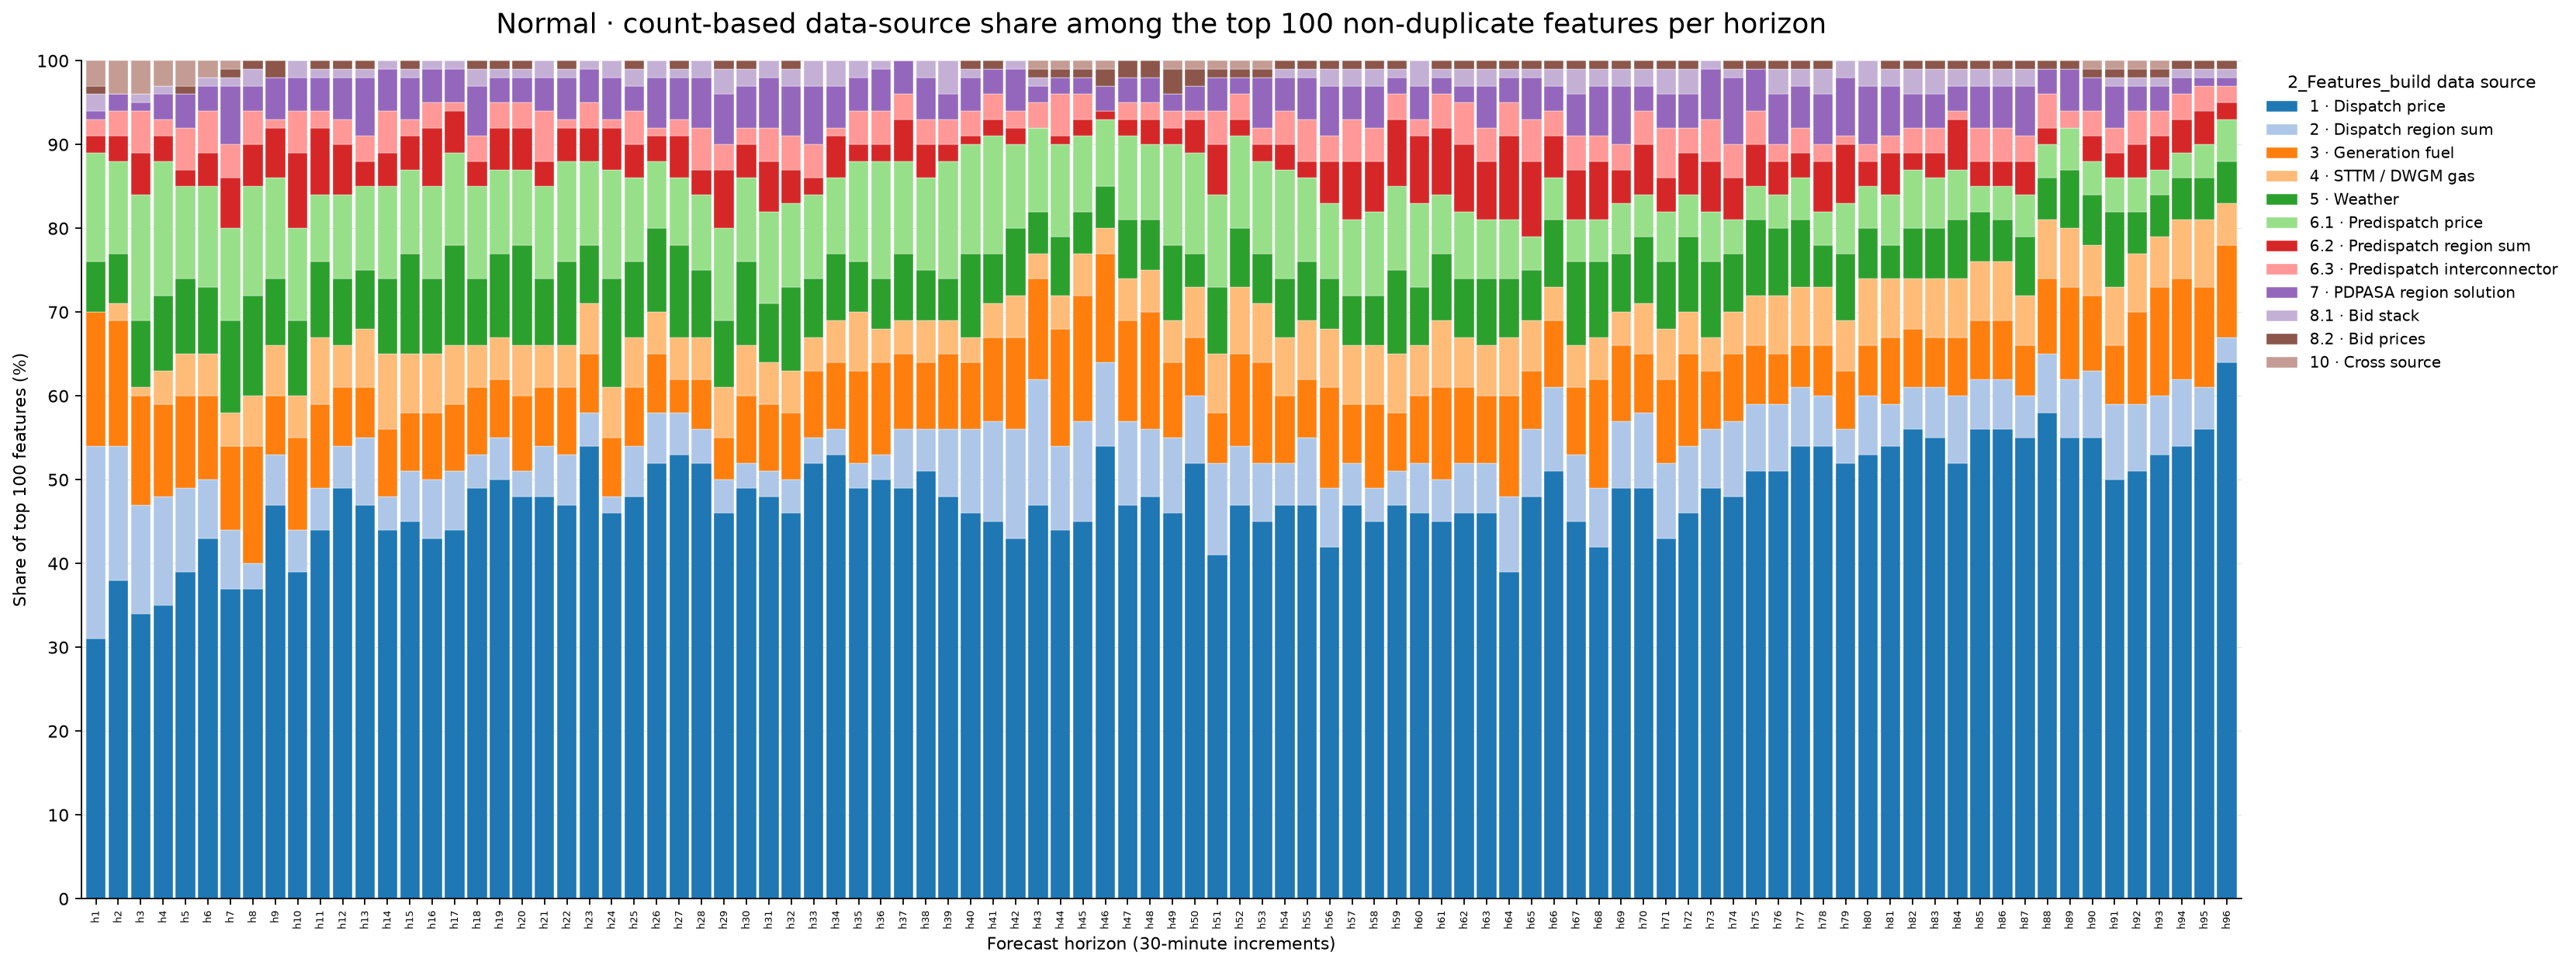

In [14]:
show_source_composition(
    "normal", source_composition_by_objective,
    "count-based", "Share of top 100 features (%)",
)


## Table 10 — Arcsinh: top-100 feature sources by horizon

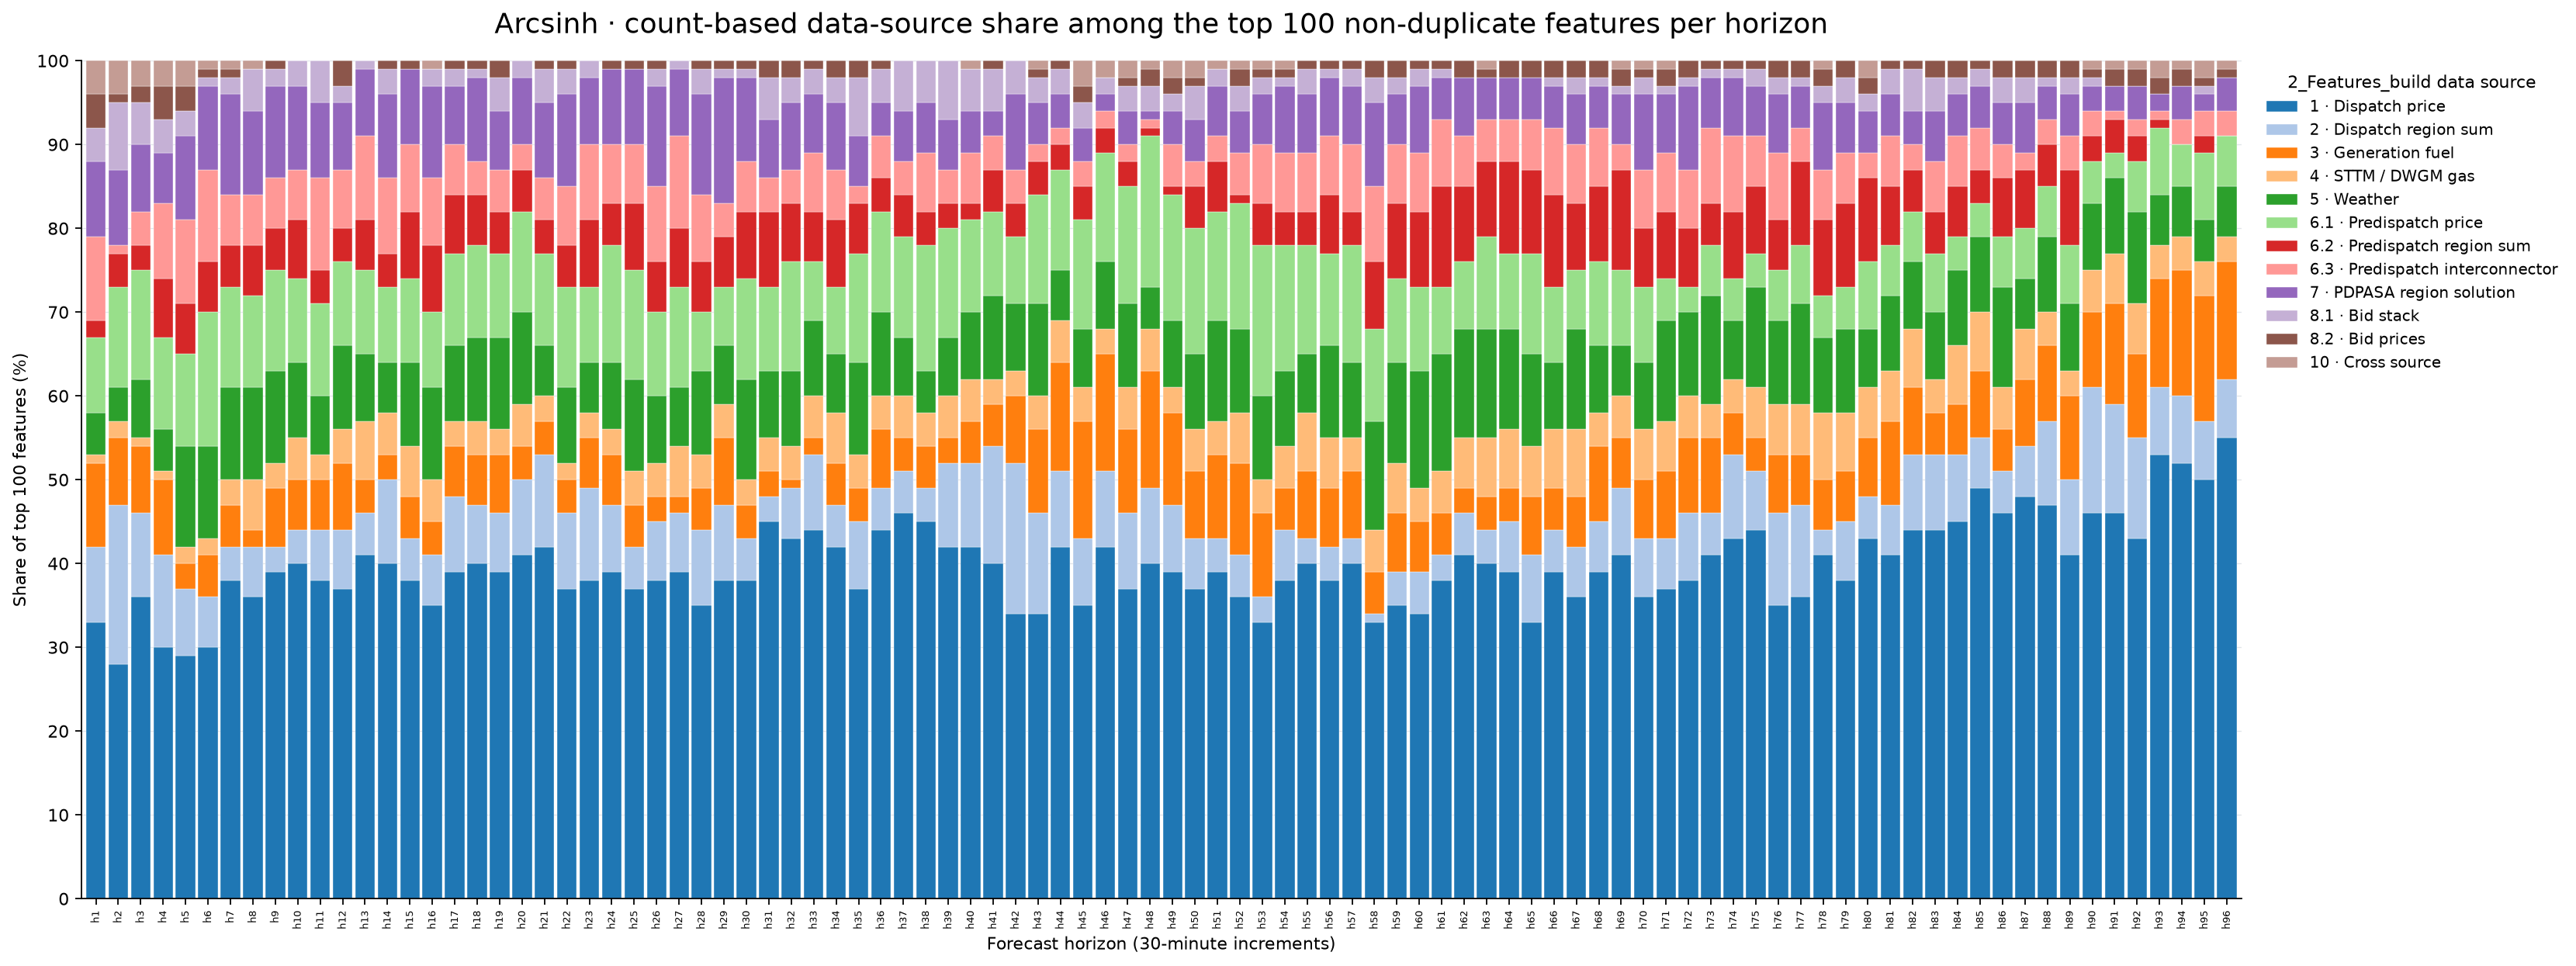

In [15]:
show_source_composition(
    "arcsinh", source_composition_by_objective,
    "count-based", "Share of top 100 features (%)",
)


## Table 11 — Spikes: top-100 feature sources by horizon

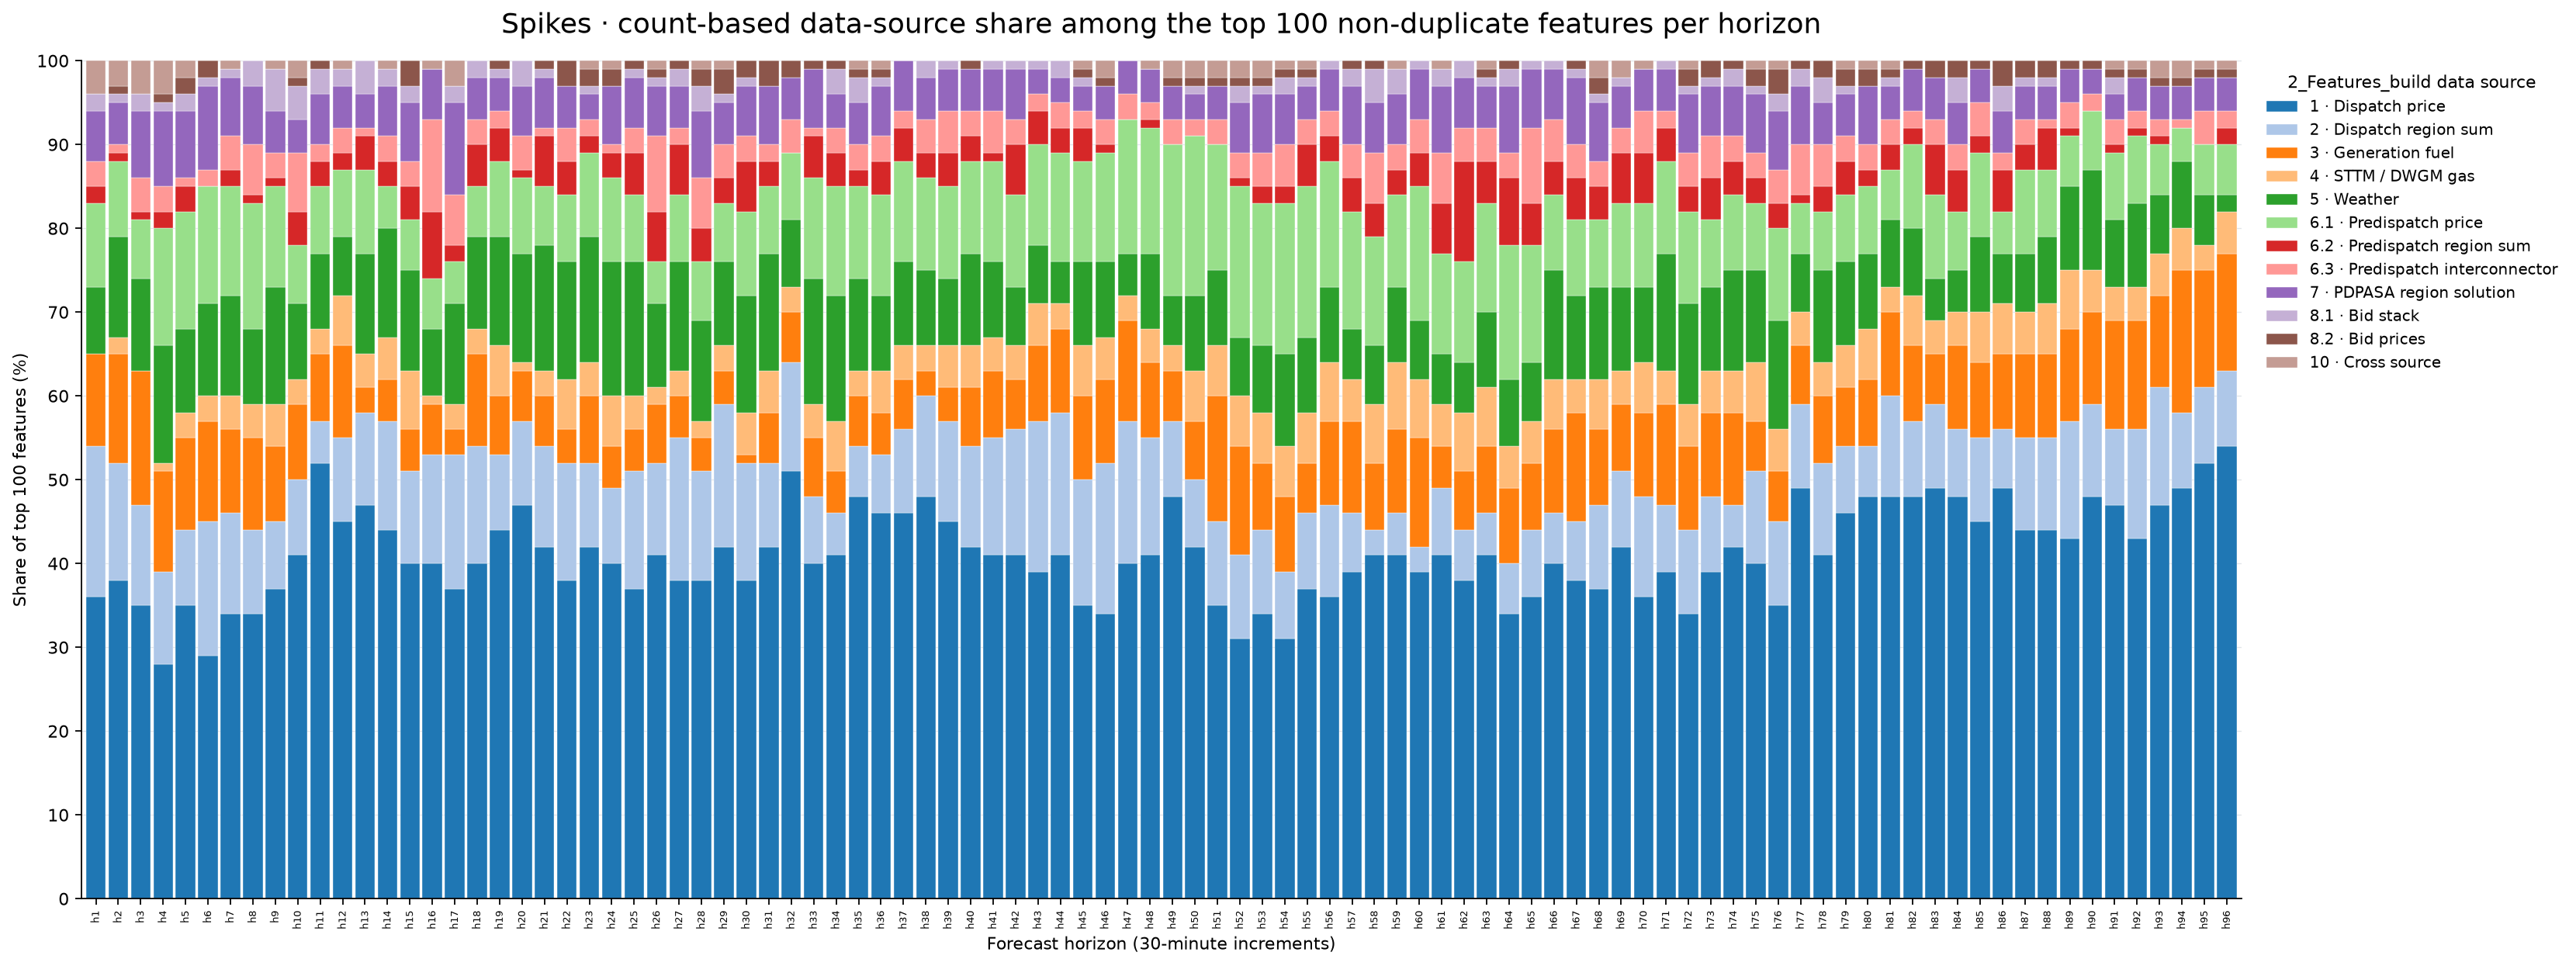

In [16]:
show_source_composition(
    "spikes", source_composition_by_objective,
    "count-based", "Share of top 100 features (%)",
)


## Table 12 — Dips: top-100 feature sources by horizon

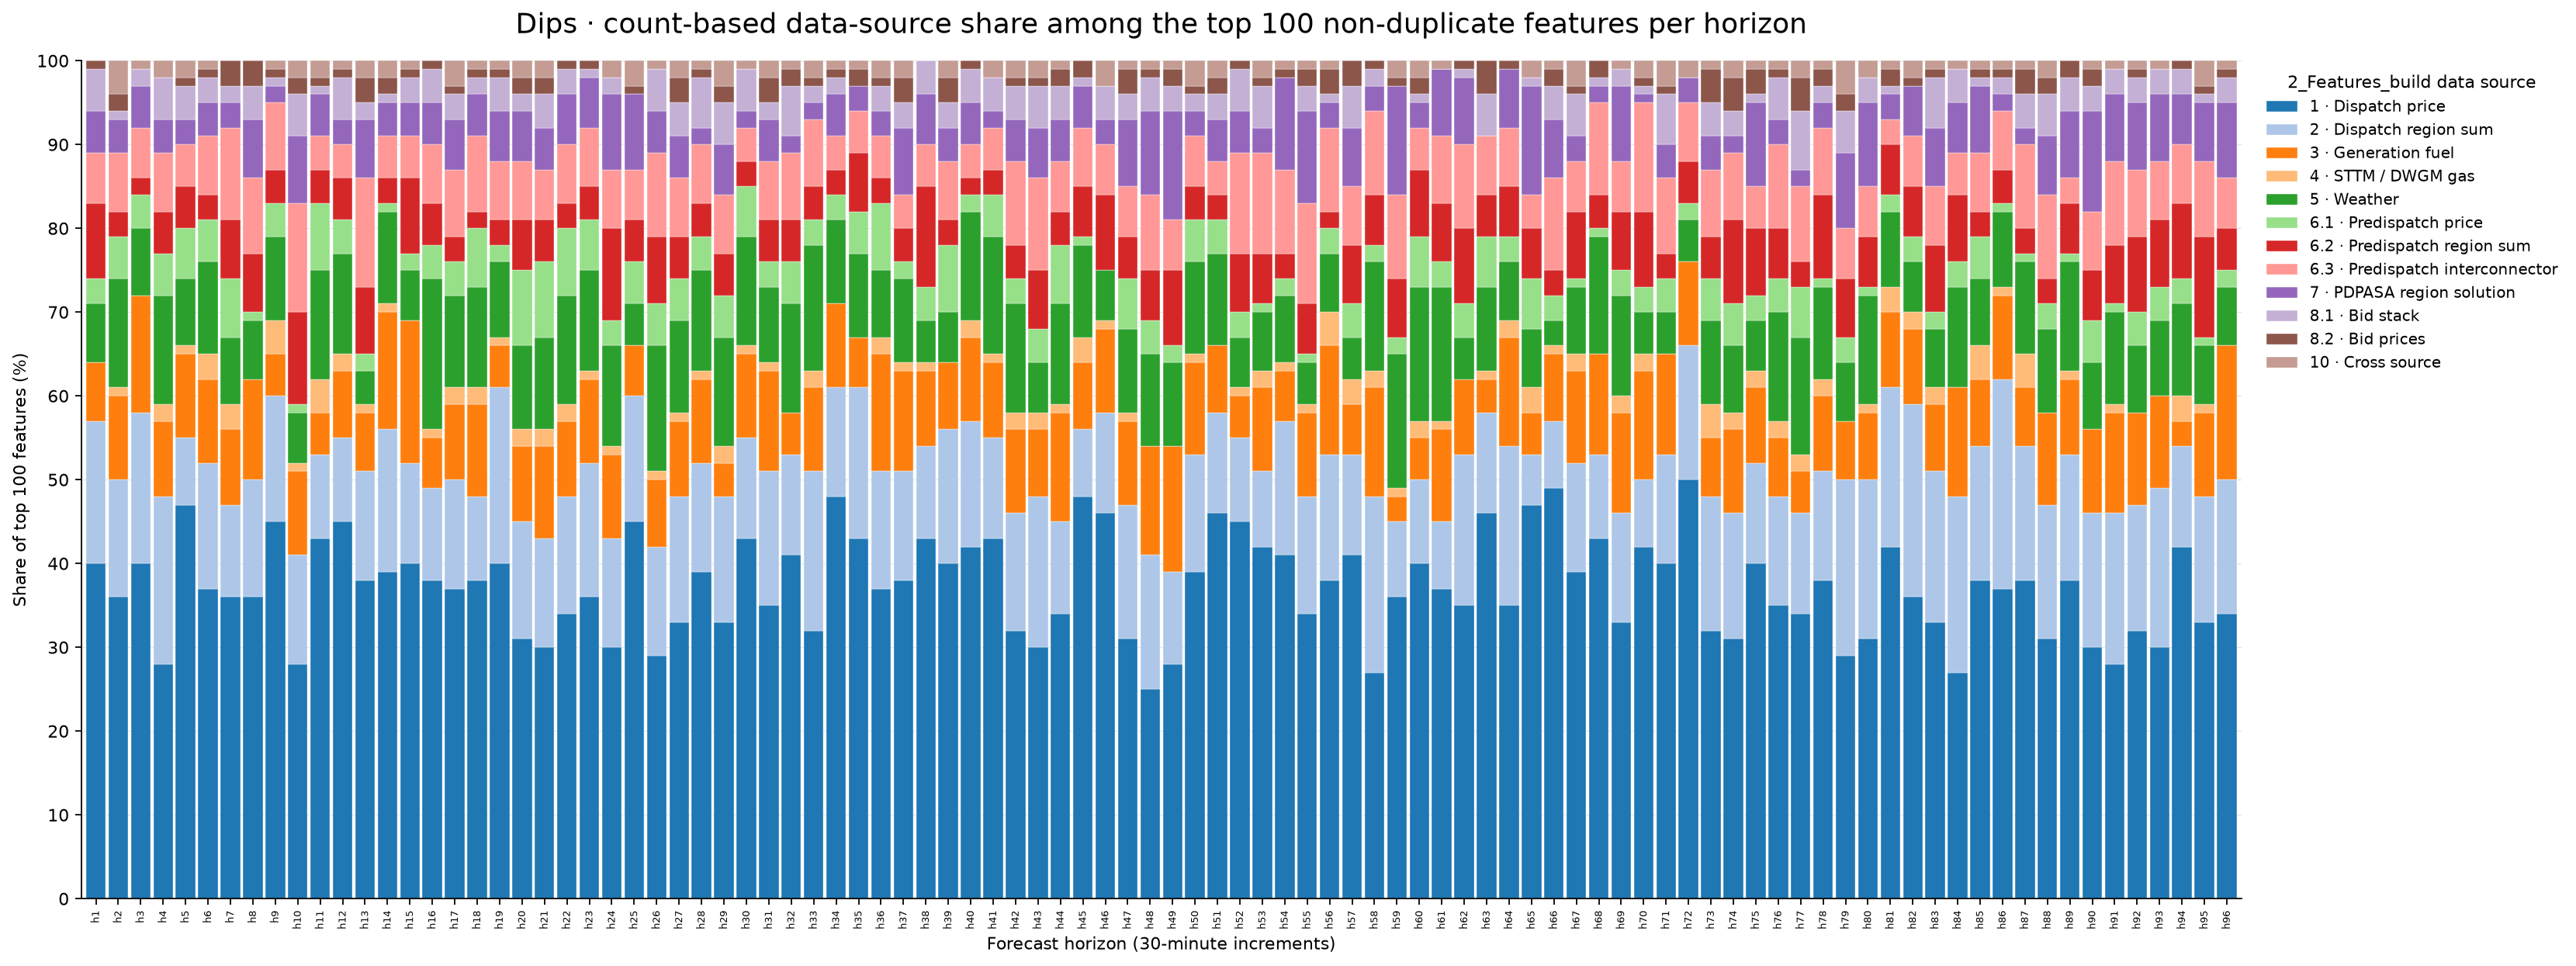

In [17]:
show_source_composition(
    "dips", source_composition_by_objective,
    "count-based", "Share of top 100 features (%)",
)


# Importance-weighted data-source composition

These four charts use the same top 100 non-duplicate features per horizon, but weight every feature by its raw LightGBM gain. For each source, the gains of its represented features are summed and divided by the total gain of the horizon's top 100 features. Each bar therefore totals 100% and shows how the information carried by those top features is distributed across source datasets.

## Table 13 — Normal: importance-weighted feature sources by horizon

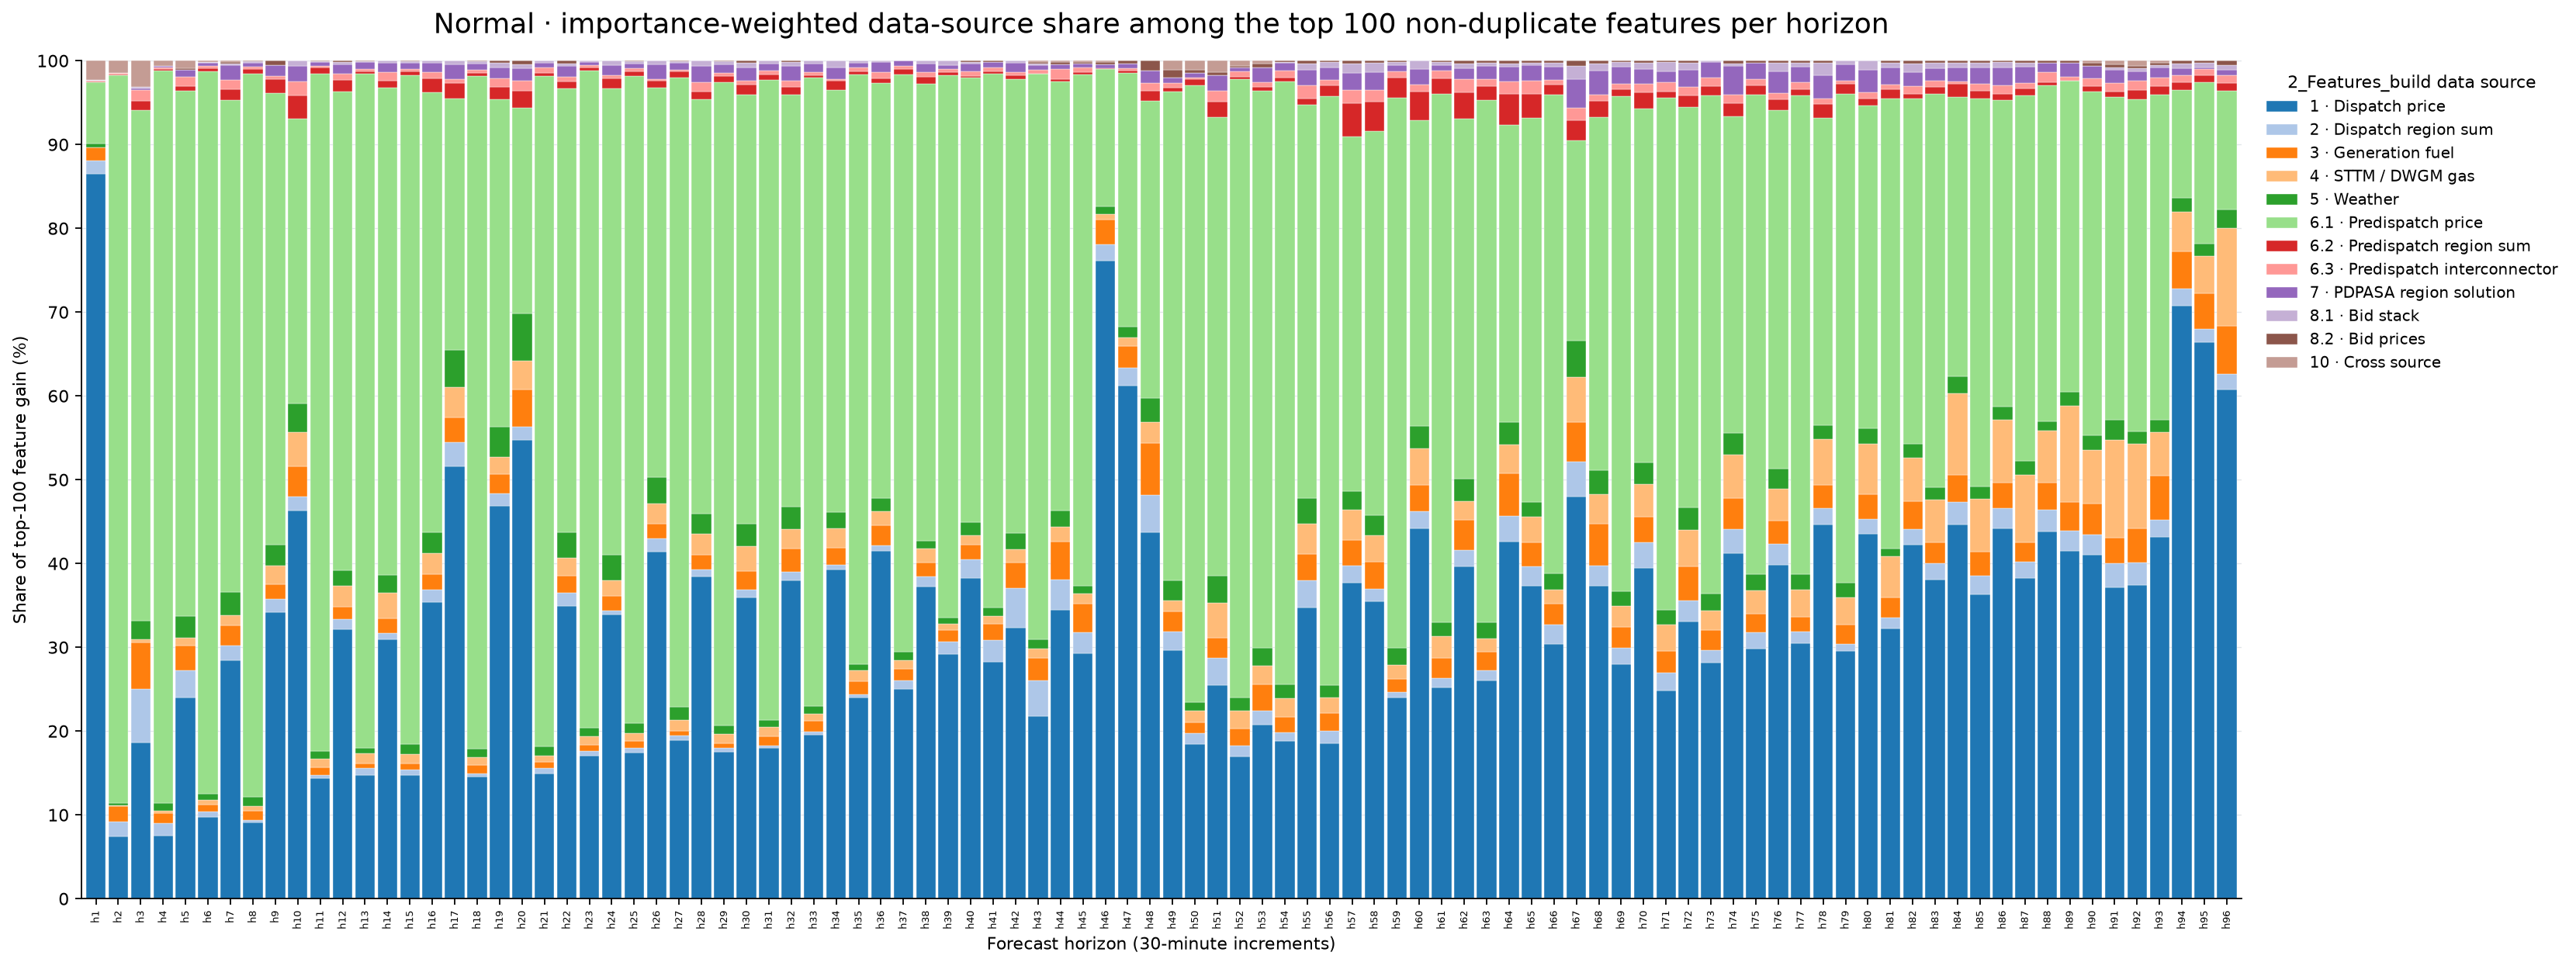

In [18]:
show_source_composition(
    "normal", weighted_source_composition_by_objective,
    "importance-weighted", "Share of top-100 feature gain (%)",
)


## Table 14 — Arcsinh: importance-weighted feature sources by horizon

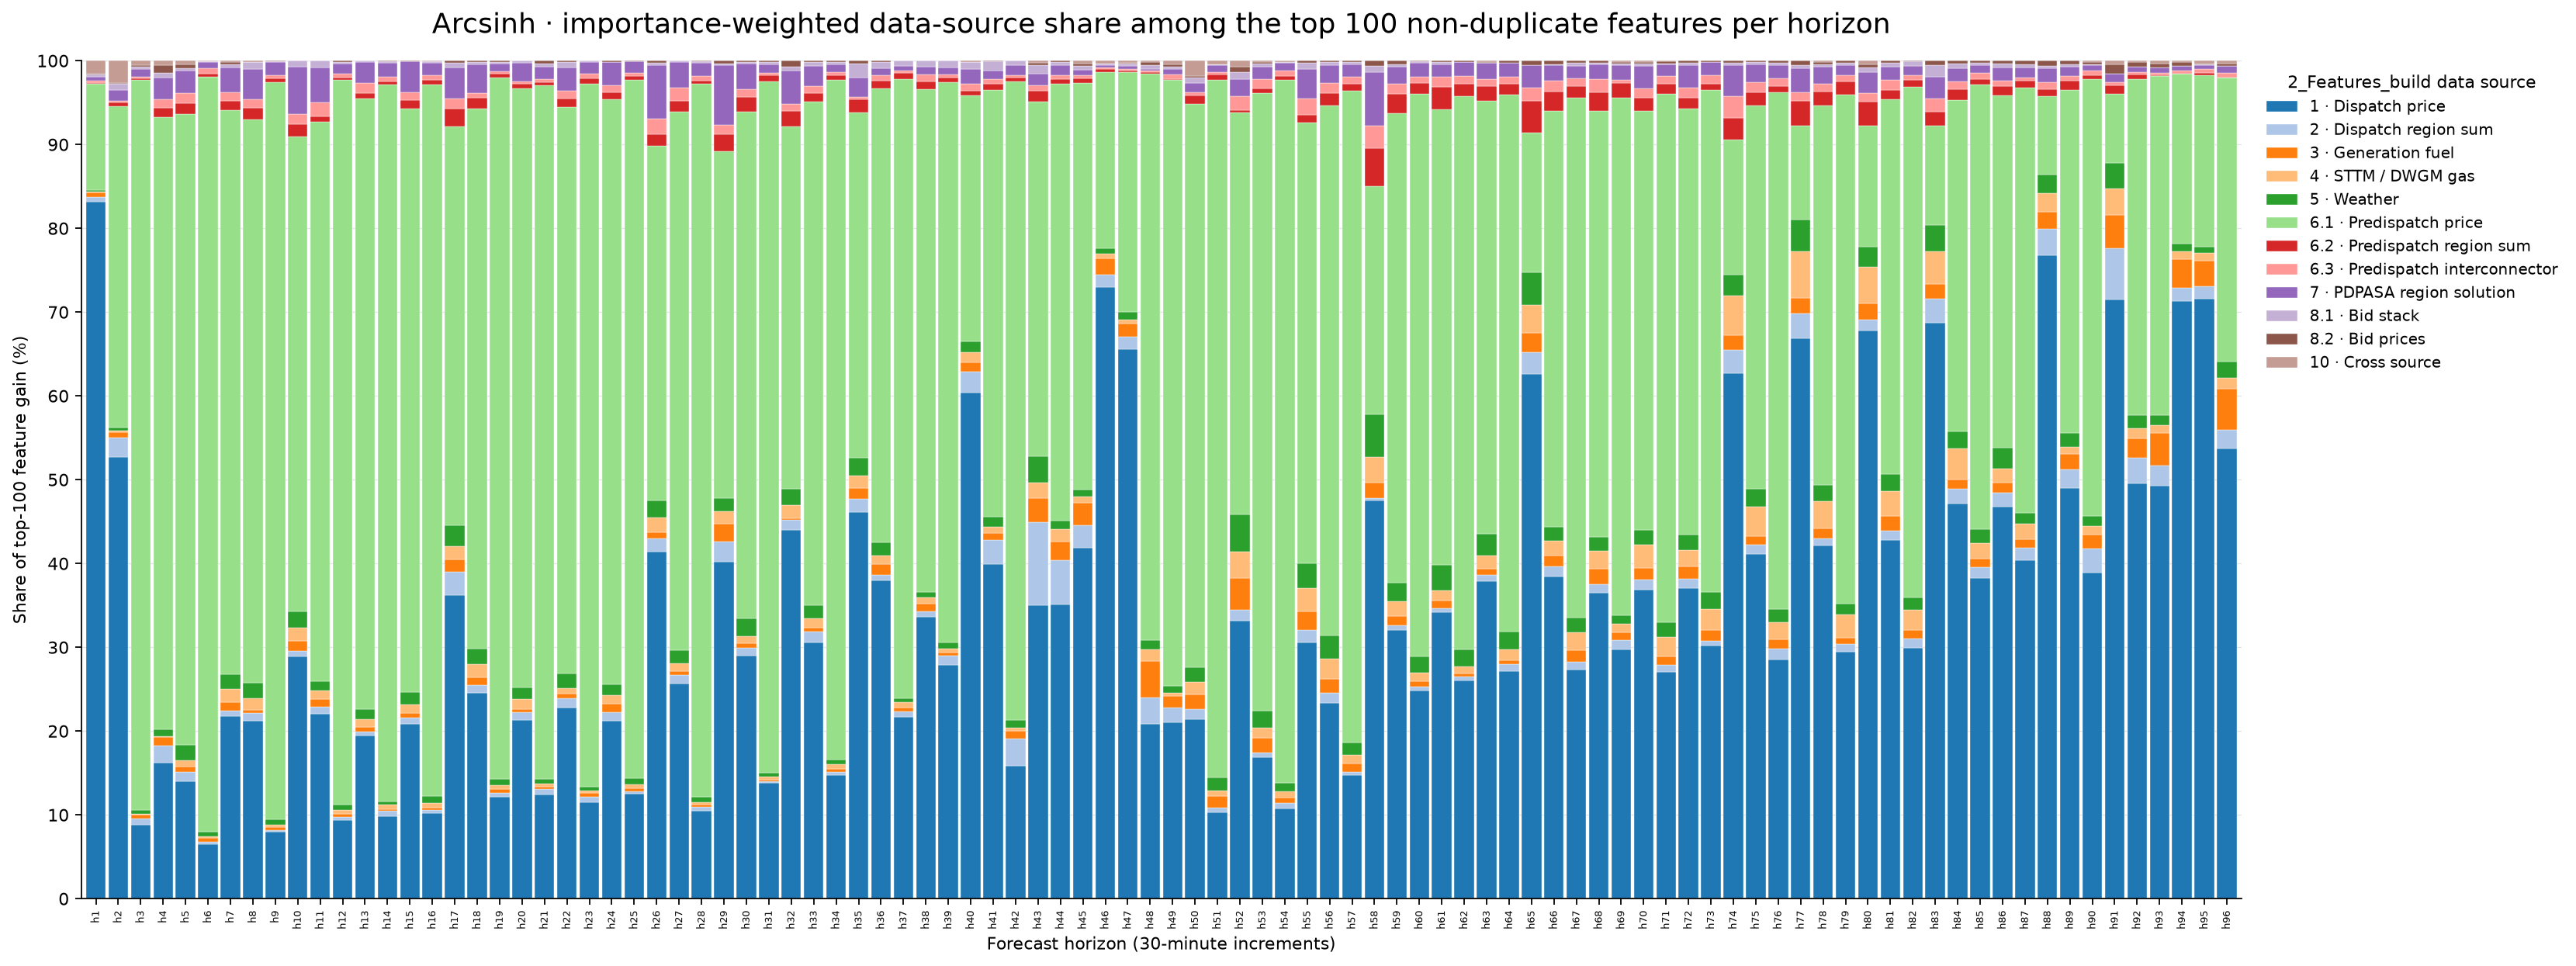

In [19]:
show_source_composition(
    "arcsinh", weighted_source_composition_by_objective,
    "importance-weighted", "Share of top-100 feature gain (%)",
)


## Table 15 — Spikes: importance-weighted feature sources by horizon

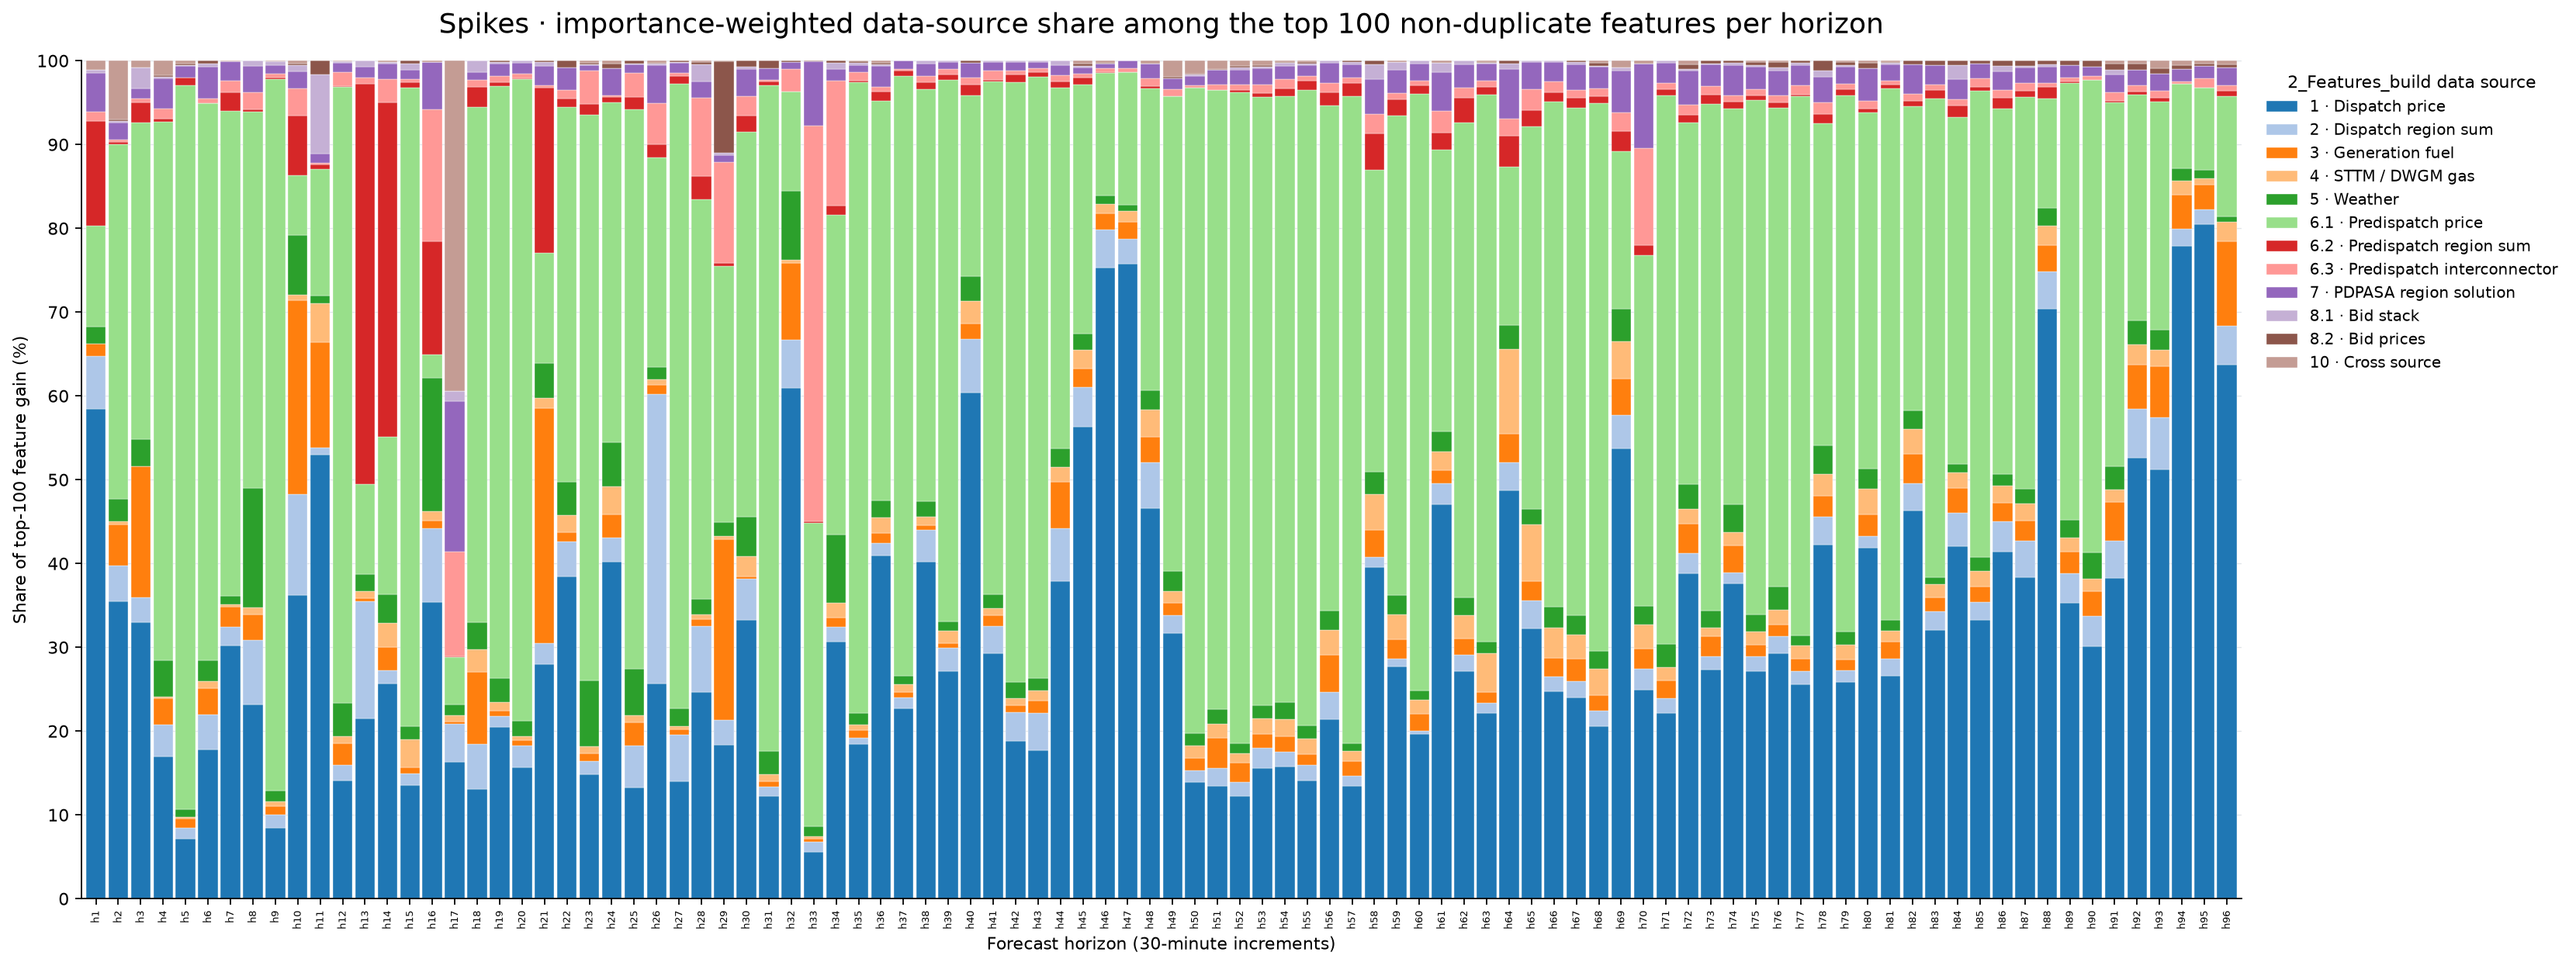

In [20]:
show_source_composition(
    "spikes", weighted_source_composition_by_objective,
    "importance-weighted", "Share of top-100 feature gain (%)",
)


## Table 16 — Dips: importance-weighted feature sources by horizon

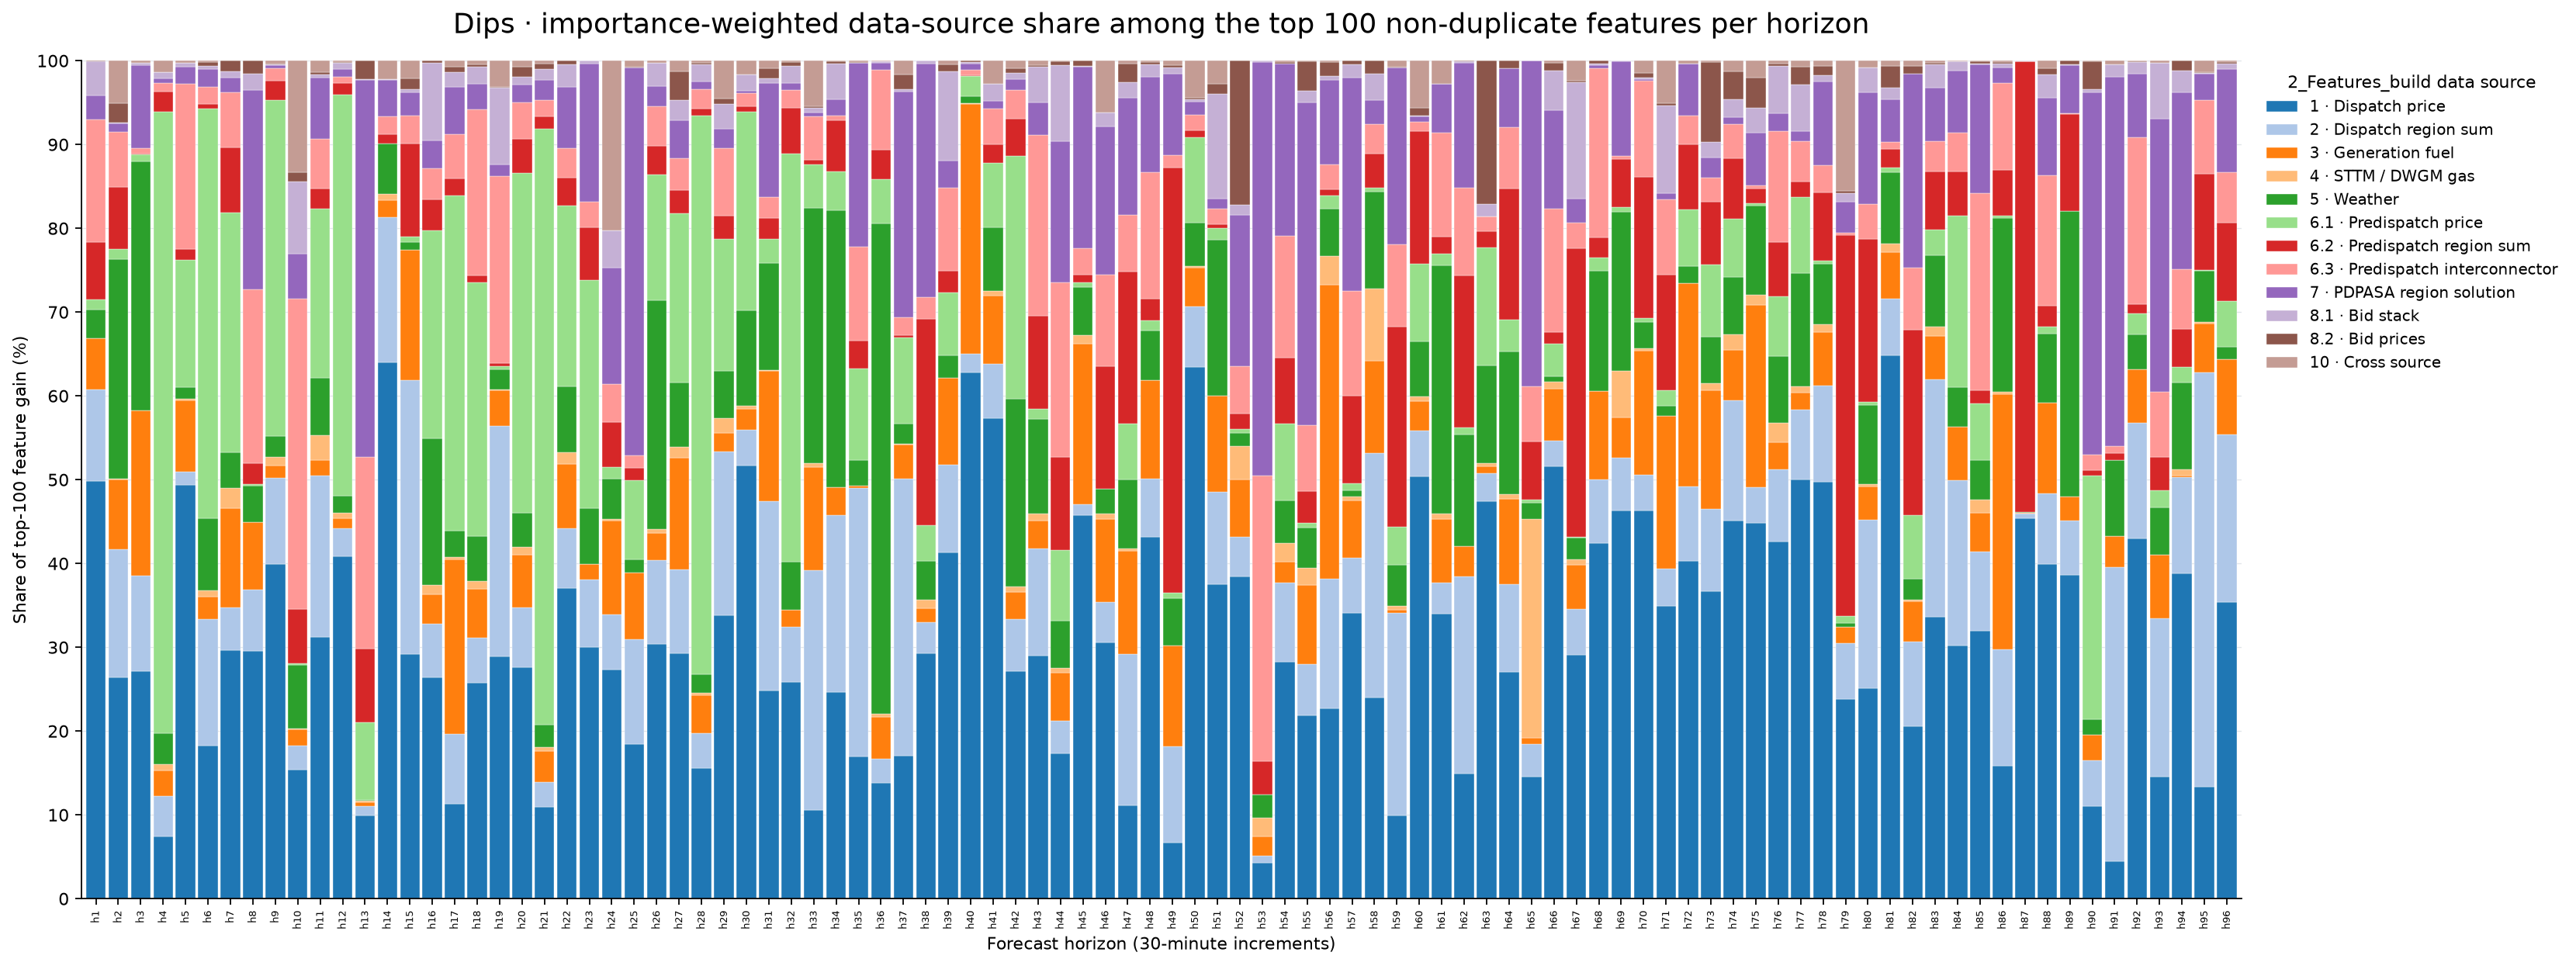

In [21]:
show_source_composition(
    "dips", weighted_source_composition_by_objective,
    "importance-weighted", "Share of top-100 feature gain (%)",
)
